In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import table
import io
import dataframe_image as dfi
import seaborn as sns

from pathlib import Path

# Define paths
DATA_PATH = Path("../../../../data/raw")


In [6]:
# ============================================
# STEP 1: IMPORT ALL NECESSARY LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # This is essential for zscore
from pathlib import Path
import warnings
import os
warnings.filterwarnings('ignore')

# ============================================
# STEP 2: DEFINE YOUR TARGET VARIABLE HERE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

# ============================================
# SET UP PROFESSIONAL COLOR PALETTES
# ============================================
print(f"\n{'='*80}")
print(f"🎨 SETTING UP COLOR PALETTES")
print(f"{'='*80}")

# Medical/Clinical color palette (intuitive for healthcare)
medical_palette = {
    'critical': '#8B0000',      # Dark Red - Extreme danger
    'very_high_risk': '#DC143C',  # Crimson - Very high risk
    'high_risk': '#FF4500',      # Orange Red - High risk
    'moderate_risk': '#FF8C00',   # Dark Orange - Moderate risk
    'elevated_risk': '#FFA500',    # Orange - Elevated risk
    'normal': '#228B22',          # Forest Green - Normal
    'optimal': '#32CD32',         # Lime Green - Optimal
    'low_risk': '#90EE90',        # Light Green - Low risk
    'very_low_risk': '#98FB98',    # Pale Green - Very low risk
    'rare': '#9370DB',            # Medium Purple - Rare cases
    'extreme': '#800080',          # Purple - Extreme cases
    'error': '#000000',            # Black - Data errors
    'statistical': '#1E90FF',      # Dodger Blue - Statistical
    'consensus': '#4169E1'         # Royal Blue - Consensus
}

# Categorical palettes for different uses
category_palette = {
    'ELBW': '#8B0000',        # Extremely Low Birth Weight - Dark Red
    'VLBW': '#DC143C',        # Very Low Birth Weight - Crimson
    'LBW': '#FF4500',         # Low Birth Weight - Orange Red
    'Normal': '#228B22',      # Normal - Forest Green
    'Macrosomia': '#FF8C00',  # Macrosomia - Dark Orange
    'Severe Macrosomia': '#FF1493',  # Severe - Deep Pink
    'Extreme': '#800080'       # Extreme - Purple
}

# Sequential palettes for gradients
red_gradient = ['#FFE4E1', '#FFC0CB', '#FFB6C1', '#FF69B4', '#FF1493', '#DC143C', '#8B0000']
green_gradient = ['#F0FFF0', '#98FB98', '#90EE90', '#32CD32', '#228B22', '#006400', '#004d00']
blue_gradient = ['#E6F3FF', '#B8DAFF', '#8AC0FF', '#5CA6FF', '#2E8BFF', '#0066CC', '#004C99']

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

print(f"✅ Color palettes configured successfully")
print(f"   • Medical palette: {len(medical_palette)} colors")
print(f"   • Category palette: {len(category_palette)} colors")
print(f"   • Gradients: Red, Green, Blue sequences")

# ============================================
# STEP 3: LOAD DATA WITH PATH HANDLING
# ============================================
print(f"\n{'='*80}")
print(f"🔍 SYSTEMATIC OUTLIER DETECTION: '{TARGET}'")
print(f"{'='*80}")

# Try multiple possible paths
possible_paths = [
    Path("../../data/raw/2020_Birth_Final.xlsx"),
    Path("../../../../data/raw/2020_Birth_Final.xlsx"),
    Path("../data/raw/2020_Birth_Final.xlsx"),
    Path("data/raw/2020_Birth_Final.xlsx"),
    Path("./data/raw/2020_Birth_Final.xlsx"),
    Path("2020_Birth_Final.xlsx"),
]

df = None
for path in possible_paths:
    if path.exists():
        print(f"✅ Found file at: {path}")
        df = pd.read_excel(path)
        break

if df is None:
    print("❌ Could not find the data file. Please check the path.")
    print("Current directory:", Path.cwd())
    print("\nFiles in current directory:")
    for f in Path.cwd().iterdir():
        print(f"  {f.name}")
    exit()

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    
    # Try to find similar columns
    similar = [col for col in df.columns if 'birth' in col.lower() or 'weight' in col.lower()]
    if similar:
        print(f"\nDid you mean one of these?")
        for col in similar:
            print(f"  • {col}")
    exit()

# Get data
original_data = df[TARGET]
data = original_data.dropna()
total_records = len(original_data)
valid_records = len(data)
missing_records = total_records - valid_records

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {total_records:,}")
print(f"   • Valid records: {valid_records:,}")
print(f"   • Missing values: {missing_records:,} ({(missing_records/total_records*100):.1f}%)")
print(f"   • Data type: {data.dtype}")
print(f"   • Range: {data.min():.1f} - {data.max():.1f}")

# ============================================
# STEP 4: STATISTICAL OUTLIER DETECTION (First Pass)
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 4: STATISTICAL OUTLIER DETECTION (FIRST PASS)")
print(f"{'─'*80}")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence_iqr = Q1 - 1.5 * IQR
upper_fence_iqr = Q3 + 1.5 * IQR

# Method 2: Extreme IQR (more stringent)
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

# Method 3: Z-score method
z_scores = np.abs(stats.zscore(data))  # Now stats is defined
z_outliers = data[z_scores > 3]

# Method 4: Modified Z-score (using median)
median = data.median()
mad = np.median(np.abs(data - median))  # Median Absolute Deviation
if mad > 0:
    modified_z_scores = 0.6745 * (data - median) / mad
else:
    modified_z_scores = np.zeros_like(data)
modified_z_outliers = data[np.abs(modified_z_scores) > 3.5]

print(f"\n📈 STATISTICAL METHODS COMPARISON:")
print(f"\n   Descriptive Statistics:")
print(f"      • Mean: {data.mean():.1f}")
print(f"      • Median: {data.median():.1f}")
print(f"      • Std Dev: {data.std():.1f}")
print(f"      • Q1 (25th): {Q1:.1f}")
print(f"      • Q3 (75th): {Q3:.1f}")
print(f"      • IQR: {IQR:.1f}")

print(f"\n   IQR Method (1.5*IQR):")
print(f"      • Lower fence: {lower_fence_iqr:.1f}")
print(f"      • Upper fence: {upper_fence_iqr:.1f}")
iqr_outliers = data[(data < lower_fence_iqr) | (data > upper_fence_iqr)]
print(f"      • Outliers: {len(iqr_outliers):,} ({len(iqr_outliers)/valid_records*100:.2f}%)")

print(f"\n   Extreme IQR Method (3*IQR):")
print(f"      • Lower fence: {lower_fence_extreme:.1f}")
print(f"      • Upper fence: {upper_fence_extreme:.1f}")
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]
print(f"      • Extreme outliers: {len(extreme_iqr_outliers):,} ({len(extreme_iqr_outliers)/valid_records*100:.2f}%)")

print(f"\n   Z-score Method (|z| > 3):")
print(f"      • Outliers: {len(z_outliers):,} ({len(z_outliers)/valid_records*100:.2f}%)")

print(f"\n   Modified Z-score Method (>3.5):")
print(f"      • Outliers: {len(modified_z_outliers):,} ({len(modified_z_outliers)/valid_records*100:.2f}%)")

# Consensus approach: outlier if identified by at least 2 methods
stat_outlier_methods = pd.DataFrame({
    'iqr': data.isin(iqr_outliers),
    'extreme_iqr': data.isin(extreme_iqr_outliers),
    'zscore': data.isin(z_outliers),
    'modified_z': data.isin(modified_z_outliers)
})
stat_outlier_methods['num_methods'] = stat_outlier_methods.sum(axis=1)

consensus_outliers = data[stat_outlier_methods['num_methods'] >= 2]
print(f"\n   ✅ CONSENSUS STATISTICAL OUTLIERS (identified by ≥2 methods):")
print(f"      • Count: {len(consensus_outliers):,} ({len(consensus_outliers)/valid_records*100:.2f}%)")

# Continue with the rest of the analysis...
# [The remaining code from your previous message continues here...]


🎨 SETTING UP COLOR PALETTES
✅ Color palettes configured successfully
   • Medical palette: 14 colors
   • Category palette: 7 colors
   • Gradients: Red, Green, Blue sequences

🔍 SYSTEMATIC OUTLIER DETECTION: 'Birth_Weight(grams)'
✅ Found file at: ..\..\..\..\data\raw\2020_Birth_Final.xlsx

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)
   • Data type: float64
   • Range: 620.0 - 7740.0

────────────────────────────────────────────────────────────────────────────────
📊 STEP 4: STATISTICAL OUTLIER DETECTION (FIRST PASS)
────────────────────────────────────────────────────────────────────────────────

📈 STATISTICAL METHODS COMPARISON:

   Descriptive Statistics:
      • Mean: 2917.7
      • Median: 2930.0
      • Std Dev: 479.9
      • Q1 (25th): 2640.0
      • Q3 (75th): 3220.0
      • IQR: 580.0

   IQR Method (1.5*IQR):
      • Lower fence: 1770.0
      • Upper fence: 4090.0
      • Outliers: 6,522 (2.43%)

   Extreme I

In [7]:
# ============================================
# STEP 1: IMPORT ALL NECESSARY LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================
# STEP 2: DEFINE YOUR TARGET VARIABLE HERE
# ============================================
TARGET = 'Birth_Weight(grams)'  # <--- CHANGE THIS to analyze different variables
# ============================================

print(f"\n{'='*80}")
print(f"🔍 COMPREHENSIVE OUTLIER ANALYSIS: '{TARGET}'")
print(f"{'='*80}")

# Check if column exists
if TARGET not in df.columns:
    print(f"❌ ERROR: Column '{TARGET}' not found!")
    print(f"Available columns: {df.columns.tolist()}")
    exit()

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]  # Keep with missing

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Missing values: {original_data.isnull().sum():,} ({(original_data.isnull().sum()/len(original_data)*100):.1f}%)")
print(f"   • Data type: {data.dtype}")
print(f"   • Range: {data.min():.1f} - {data.max():.1f}")
print(f"   • Mean: {data.mean():.1f}")
print(f"   • Median: {data.median():.1f}")
print(f"   • Std Dev: {data.std():.1f}")

# ============================================
# STEP 3: DEFINE MEDICAL THRESHOLDS (WHO)
# ============================================
print(f"\n{'─'*80}")
print(f"📋 STEP 3: WHO MEDICAL THRESHOLDS")
print(f"{'─'*80}")

# Birth weight thresholds (WHO)
medical_thresholds = {
    'Extremely Low Birth Weight (ELBW)': {
        'min': 0, 'max': 999, 
        'color': '#8B0000', 'risk': 'Critical',
        'description': 'Extremely high risk - requires intensive care',
        'action': 'Immediate NICU admission'
    },
    'Very Low Birth Weight (VLBW)': {
        'min': 1000, 'max': 1499, 
        'color': '#DC143C', 'risk': 'Very High',
        'description': 'Very high risk - requires specialized care',
        'action': 'NICU admission required'
    },
    'Low Birth Weight (LBW)': {
        'min': 1500, 'max': 2499, 
        'color': '#FF4500', 'risk': 'High',
        'description': 'Moderate risk - may require monitoring',
        'action': 'Special care nursery'
    },
    'Normal Birth Weight': {
        'min': 2500, 'max': 4499, 
        'color': '#228B22', 'risk': 'Low',
        'description': 'Healthy weight range',
        'action': 'Routine care'
    },
    'Macrosomia (High Birth Weight)': {
        'min': 4500, 'max': 4999, 
        'color': '#FF8C00', 'risk': 'Moderate',
        'description': 'Risk of birth complications',
        'action': 'Monitor for shoulder dystocia'
    },
    'Severe Macrosomia': {
        'min': 5000, 'max': 5499, 
        'color': '#FF1493', 'risk': 'High',
        'description': 'Very high risk of complications',
        'action': 'Prepare for C-section'
    },
    'Extreme Macrosomia': {
        'min': 5500, 'max': 5999, 
        'color': '#800080', 'risk': 'Very High',
        'description': 'Exceptional cases, extremely rare',
        'action': 'Multidisciplinary team required'
    },
    'Not Biologically Plausible': {
        'min': 6000, 'max': float('inf'), 
        'color': '#000000', 'risk': 'Error',
        'description': 'Likely data entry error',
        'action': 'Verify source data'
    }
}

unit = 'grams'
normal_range = "2,500 - 4,499 grams"

print(f"\n   Variable: {TARGET}")
print(f"   WHO Reference: {normal_range}")
print(f"   Unit: {unit}")
print(f"\n   WHO Categories:")
for category, details in medical_thresholds.items():
    max_val = '∞' if details['max'] == float('inf') else f"{details['max']:,}"
    print(f"      • {category}: {details['min']:,} - {max_val} {unit} [{details['risk']} Risk]")

# ============================================
# STEP 4: STATISTICAL OUTLIER DETECTION
# ============================================
print(f"\n{'─'*80}")
print(f"📊 STEP 4: STATISTICAL OUTLIER DETECTION")
print(f"{'─'*80}")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

# Method 2: Z-score method
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]
z_extreme = data[z_scores > 4]

# Method 3: Modified Z-score (robust)
median = data.median()
mad = np.median(np.abs(data - median))
if mad > 0:
    modified_z = 0.6745 * (data - median) / mad
else:
    modified_z = np.zeros_like(data)
mod_z_outliers = data[np.abs(modified_z) > 3.5]

print(f"\n📈 STATISTICAL METHODS RESULTS:")
print(f"\n   Descriptive Statistics:")
print(f"      • Mean: {data.mean():.1f}")
print(f"      • Median: {data.median():.1f}")
print(f"      • Q1 (25th): {Q1:.1f}")
print(f"      • Q3 (75th): {Q3:.1f}")
print(f"      • IQR: {IQR:.1f}")

print(f"\n   IQR Method (1.5*IQR):")
print(f"      • Lower fence: {lower_fence:.1f}")
print(f"      • Upper fence: {upper_fence:.1f}")
iqr_outliers = data[(data < lower_fence) | (data > upper_fence)]
print(f"      • Mild outliers: {len(iqr_outliers):,} ({len(iqr_outliers)/len(data)*100:.2f}%)")

print(f"\n   Extreme IQR Method (3*IQR):")
print(f"      • Lower fence: {lower_fence_extreme:.1f}")
print(f"      • Upper fence: {upper_fence_extreme:.1f}")
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]
print(f"      • Extreme outliers: {len(extreme_iqr_outliers):,} ({len(extreme_iqr_outliers)/len(data)*100:.2f}%)")

print(f"\n   Z-score Method:")
print(f"      • |z| > 3 (outliers): {len(z_outliers):,} ({len(z_outliers)/len(data)*100:.2f}%)")
print(f"      • |z| > 4 (extreme): {len(z_extreme):,} ({len(z_extreme)/len(data)*100:.2f}%)")

print(f"\n   Modified Z-score Method:")
print(f"      • Outliers: {len(mod_z_outliers):,} ({len(mod_z_outliers)/len(data)*100:.2f}%)")

# ============================================
# STEP 5: CLASSIFY ALL RECORDS
# ============================================
print(f"\n{'─'*80}")
print(f"📋 STEP 5: CLASSIFYING ALL RECORDS")
print(f"{'─'*80}")

# Create classification DataFrame
classification = []
for value in data:
    for category, details in medical_thresholds.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'medical_category': category,
                'risk_level': details['risk'],
                'description': details['description'],
                'action': details['action'],
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Calculate z-scores for all values
class_df['z_score'] = np.abs(stats.zscore(class_df['value']))

# Add statistical outlier flags AFTER creating class_df
class_df['is_iqr_outlier'] = class_df['value'].isin(iqr_outliers)
class_df['is_extreme_iqr'] = class_df['value'].isin(extreme_iqr_outliers)
class_df['is_z_outlier'] = class_df['value'].isin(z_outliers)
class_df['is_mod_z_outlier'] = class_df['value'].isin(mod_z_outliers)

# Create consensus outlier flag (identified by at least 2 methods)
class_df['methods_count'] = (
    class_df['is_iqr_outlier'].astype(int) + 
    class_df['is_extreme_iqr'].astype(int) + 
    class_df['is_z_outlier'].astype(int) + 
    class_df['is_mod_z_outlier'].astype(int)
)
class_df['is_stat_outlier'] = class_df['methods_count'] >= 2
class_df['is_extreme_stat'] = class_df['is_extreme_iqr'] | (class_df['z_score'] > 4)

# Summary by medical category
medical_summary = class_df.groupby(['medical_category', 'risk_level']).agg({
    'value': ['count', 'mean', 'min', 'max', 'std'],
    'is_stat_outlier': 'sum',
    'is_extreme_stat': 'sum'
}).round(2)
medical_summary.columns = ['Count', 'Mean', 'Min', 'Max', 'StdDev', 'Stat_Outliers', 'Extreme_Stat']
medical_summary = medical_summary.reset_index()

print(f"\n📊 MEDICAL CLASSIFICATION SUMMARY:")
print(medical_summary.to_string(index=False))

# Calculate percentages
total_valid = len(data)
print(f"\n   Total valid records: {total_valid:,}")
for _, row in medical_summary.iterrows():
    pct = (row['Count'] / total_valid * 100)
    stat_pct = (row['Stat_Outliers'] / row['Count'] * 100) if row['Count'] > 0 else 0
    print(f"   • {row['medical_category']}: {row['Count']:,} ({pct:.1f}%) - {row['Stat_Outliers']} statistical outliers ({stat_pct:.1f}% of category)")

# ============================================
# STEP 6: IDENTIFY DIFFERENT TYPES OF OUTLIERS
# ============================================
print(f"\n{'─'*80}")
print(f"🎯 STEP 6: IDENTIFYING DIFFERENT OUTLIER TYPES")
print(f"{'─'*80}")

# Type 1: Statistical outliers that are medically normal
false_positives = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] == 'Normal Birth Weight')
]

# Type 2: Medical outliers that are not statistical outliers
medical_only = class_df[
    (~class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 3: Both statistical and medical outliers
true_outliers = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 4: Extreme low birth weight (<1500g)
extreme_low = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 'Very Low Birth Weight (VLBW)']))
]

# Type 5: Extreme high birth weight (≥5000g)
extreme_high = class_df[
    (class_df['medical_category'].isin(['Severe Macrosomia', 'Extreme Macrosomia']))
]

# Type 6: Biologically implausible values
implausible = class_df[
    (class_df['medical_category'] == 'Not Biologically Plausible') |
    (class_df['value'] < 300)  # Below viable weight
]

print(f"\n📊 OUTLIER TYPE ANALYSIS:")

print(f"\n   Type 1 - FALSE POSITIVES (Statistical but Medically Normal):")
print(f"      • Count: {len(false_positives):,}")
if len(false_positives) > 0:
    print(f"      • Range: {false_positives['value'].min():.0f} - {false_positives['value'].max():.0f}g")
    print(f"      • Mean: {false_positives['value'].mean():.0f}g")
    print(f"      • These are normal weights flagged by statistics only")

print(f"\n   Type 2 - MEDICAL ONLY (Medically Abnormal but Not Statistical):")
print(f"      • Count: {len(medical_only):,}")
if len(medical_only) > 0:
    print(f"      • Categories:")
    for cat in medical_only['medical_category'].unique():
        cat_count = len(medical_only[medical_only['medical_category'] == cat])
        print(f"         - {cat}: {cat_count}")
    print(f"      • These are clinically significant but not statistical outliers")

print(f"\n   Type 3 - TRUE OUTLIERS (Both Statistical and Medical):")
print(f"      • Count: {len(true_outliers):,}")
if len(true_outliers) > 0:
    print(f"      • Categories:")
    for cat in true_outliers['medical_category'].unique():
        cat_count = len(true_outliers[true_outliers['medical_category'] == cat])
        print(f"         - {cat}: {cat_count}")

print(f"\n   Type 4 - EXTREME LOW BIRTH WEIGHT (<1500g):")
print(f"      • Count: {len(extreme_low):,}")
if len(extreme_low) > 0:
    print(f"      • Range: {extreme_low['value'].min():.0f} - {extreme_low['value'].max():.0f}g")
    print(f"      • Mean: {extreme_low['value'].mean():.0f}g")
    print(f"      • Clinical significance: These babies need intensive care")

print(f"\n   Type 5 - EXTREME HIGH BIRTH WEIGHT (≥5000g):")
print(f"      • Count: {len(extreme_high):,}")
if len(extreme_high) > 0:
    print(f"      • Range: {extreme_high['value'].min():.0f} - {extreme_high['value'].max():.0f}g")
    print(f"      • Mean: {extreme_high['value'].mean():.0f}g")
    print(f"      • Clinical significance: High risk of birth complications")

print(f"\n   Type 6 - BIOLOGICALLY IMPLAUSIBLE VALUES:")
print(f"      • Count: {len(implausible):,}")
if len(implausible) > 0:
    print(f"      • Values: {sorted(implausible['value'].tolist())}")
    print(f"      • Action: These likely need verification or removal")

# ============================================
# STEP 7: DETAILED OUTLIER INTERPRETATION
# ============================================
print(f"\n{'─'*80}")
print(f"📝 STEP 7: OUTLIER INTERPRETATION")
print(f"{'─'*80}")

print(f"\n{'='*60}")
print("INTERPRETATION 1: STATISTICAL OUTLIERS")
print('='*60)

print(f"\nBased on statistical methods, we identified {len(class_df[class_df['is_stat_outlier']])} outliers ({len(class_df[class_df['is_stat_outlier']])/len(data)*100:.1f}% of data).")
print(f"\nThese are values that deviate significantly from the distribution:")
print(f"   • Below lower fence ({lower_fence:.0f}g): {len(data[data < lower_fence])} values")
print(f"   • Above upper fence ({upper_fence:.0f}g): {len(data[data > upper_fence])} values")

print(f"\nStatistical outliers by medical category:")
for cat in class_df[class_df['is_stat_outlier']]['medical_category'].unique():
    cat_count = len(class_df[(class_df['is_stat_outlier']) & (class_df['medical_category'] == cat)])
    cat_total = len(class_df[class_df['medical_category'] == cat])
    print(f"   • {cat}: {cat_count}/{cat_total} ({cat_count/cat_total*100:.1f}% of category)")

print(f"\n{'='*60}")
print("INTERPRETATION 2: CLINICAL OUTLIERS (WHO Definition)")
print('='*60)

clinical_outliers = class_df[class_df['medical_category'] != 'Normal Birth Weight']
print(f"\nBased on WHO criteria, we identified {len(clinical_outliers)} clinical outliers ({len(clinical_outliers)/len(data)*100:.1f}% of data).")
print(f"These are medically significant cases that require attention:")

print(f"\n   LOW BIRTH WEIGHT SPECTRUM (<2500g):")
lbw_cases = class_df[class_df['value'] < 2500]
if len(lbw_cases) > 0:
    print(f"      • Total LBW cases: {len(lbw_cases)}")
    print(f"      • ELBW (<1000g): {len(class_df[class_df['value'] < 1000])}")
    print(f"      • VLBW (1000-1499g): {len(class_df[(class_df['value'] >= 1000) & (class_df['value'] < 1500)])}")
    print(f"      • LBW (1500-2499g): {len(class_df[(class_df['value'] >= 1500) & (class_df['value'] < 2500)])}")

print(f"\n   HIGH BIRTH WEIGHT SPECTRUM (>4499g):")
hbw_cases = class_df[class_df['value'] > 4499]
if len(hbw_cases) > 0:
    print(f"      • Total high weight cases: {len(hbw_cases)}")
    print(f"      • Macrosomia (4500-4999g): {len(class_df[(class_df['value'] >= 4500) & (class_df['value'] < 5000)])}")
    print(f"      • Severe (5000-5499g): {len(class_df[(class_df['value'] >= 5000) & (class_df['value'] < 5500)])}")
    print(f"      • Extreme (≥5500g): {len(class_df[class_df['value'] >= 5500])}")

# ============================================
# STEP 8: EXTREME VALUES NOT IN NORMAL DISTRIBUTION
# ============================================
print(f"\n{'─'*80}")
print(f"⚠️ STEP 8: EXTREME VALUES OUTSIDE NORMAL DISTRIBUTION")
print(f"{'─'*80}")

# Define what's considered "extreme" (beyond 3 standard deviations)
mean = data.mean()
std = data.std()
extreme_threshold_low = mean - 3*std
extreme_threshold_high = mean + 3*std

extreme_values = class_df[
    (class_df['value'] < extreme_threshold_low) | 
    (class_df['value'] > extreme_threshold_high)
]

print(f"\nValues beyond 3 standard deviations from mean:")
print(f"   • Mean ± 3σ range: {extreme_threshold_low:.0f}g - {extreme_threshold_high:.0f}g")
print(f"   • Extreme values count: {len(extreme_values)}")

if len(extreme_values) > 0:
    print(f"\n   Extreme values by category:")
    for cat in extreme_values['medical_category'].unique():
        cat_count = len(extreme_values[extreme_values['medical_category'] == cat])
        cat_data = extreme_values[extreme_values['medical_category'] == cat]
        print(f"      • {cat}: {cat_count} values")
        print(f"         Range: {cat_data['value'].min():.0f} - {cat_data['value'].max():.0f}g")
        print(f"         Mean: {cat_data['value'].mean():.0f}g")

# Values not typically seen in normal birth weight distribution
print(f"\n   RARE CLINICAL CASES (unusual even among outliers):")
rare_cases = class_df[
    (class_df['medical_category'].isin(['Extreme Macrosomia', 'Not Biologically Plausible'])) |
    (class_df['value'] < 500)  # Extremely rare below 500g
]
if len(rare_cases) > 0:
    for _, case in rare_cases.iterrows():
        print(f"      • {case['value']:.0f}g - {case['medical_category']}")
        print(f"        Action: {case['action']}")

# Continue with visualizations and Excel export...
# [The visualization and Excel export code remains the same as before]


🔍 COMPREHENSIVE OUTLIER ANALYSIS: 'Birth_Weight(grams)'

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Missing values: 33,542 (11.1%)
   • Data type: float64
   • Range: 620.0 - 7740.0
   • Mean: 2917.7
   • Median: 2930.0
   • Std Dev: 479.9

────────────────────────────────────────────────────────────────────────────────
📋 STEP 3: WHO MEDICAL THRESHOLDS
────────────────────────────────────────────────────────────────────────────────

   Variable: Birth_Weight(grams)
   WHO Reference: 2,500 - 4,499 grams
   Unit: grams

   WHO Categories:
      • Extremely Low Birth Weight (ELBW): 0 - 999 grams [Critical Risk]
      • Very Low Birth Weight (VLBW): 1,000 - 1,499 grams [Very High Risk]
      • Low Birth Weight (LBW): 1,500 - 2,499 grams [High Risk]
      • Normal Birth Weight: 2,500 - 4,499 grams [Low Risk]
      • Macrosomia (High Birth Weight): 4,500 - 4,999 grams [Moderate Risk]
      • Severe Macrosomia: 5,000 - 5,499 grams [High Risk]
      • Ext

Loading data...
✅ Data loaded: 268170 valid records

Calculating statistical outliers...
✅ Statistical calculations complete

Classifying by WHO categories...
✅ Classification complete

Identifying outlier types...
✅ Outlier types identified

GENERATING INDIVIDUAL GRAPHS


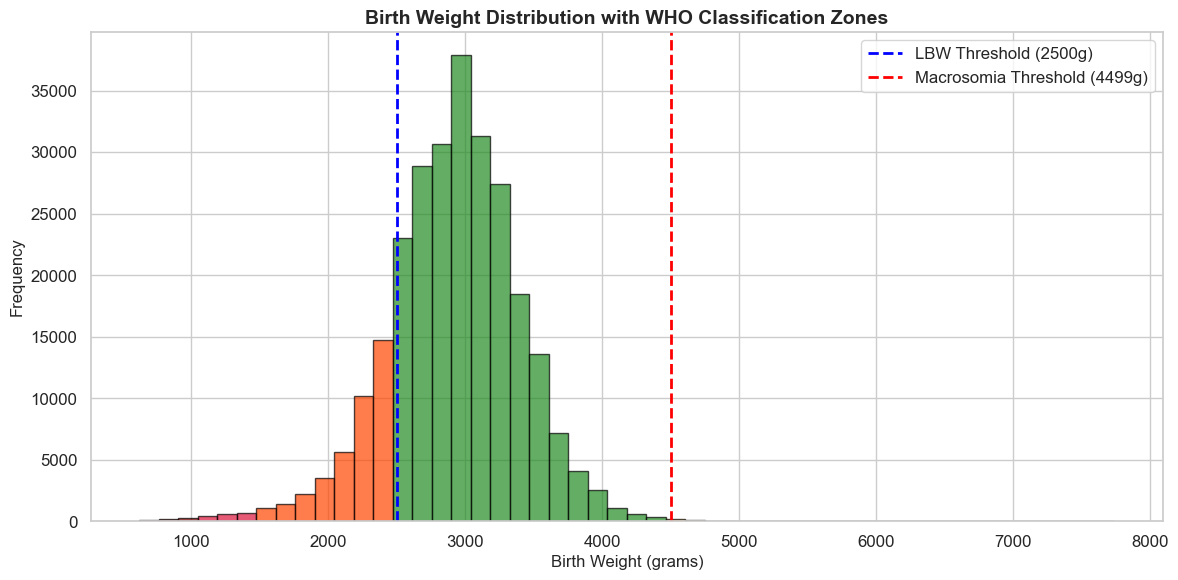

✅ Saved: 1_birth_weight_distribution.png


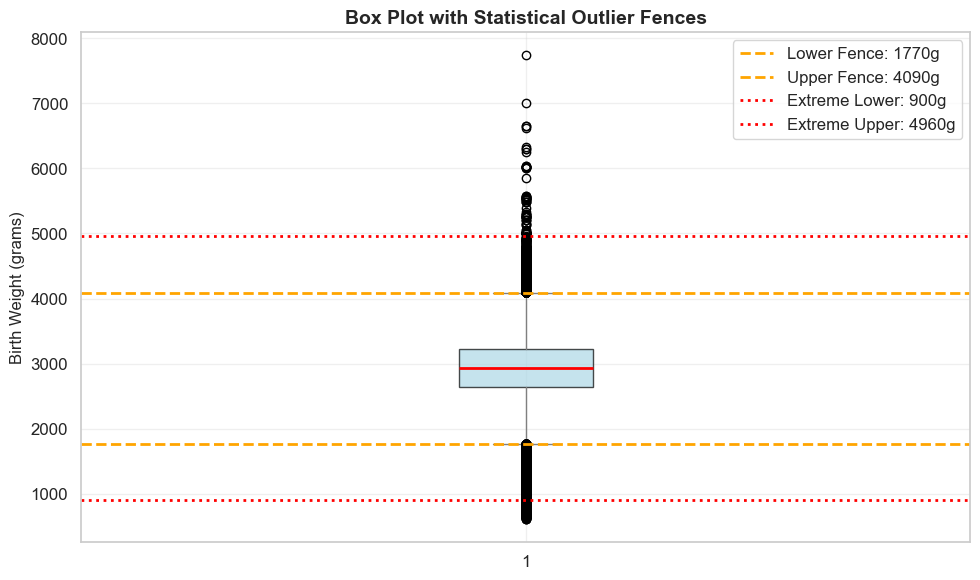

✅ Saved: 2_boxplot_fences.png


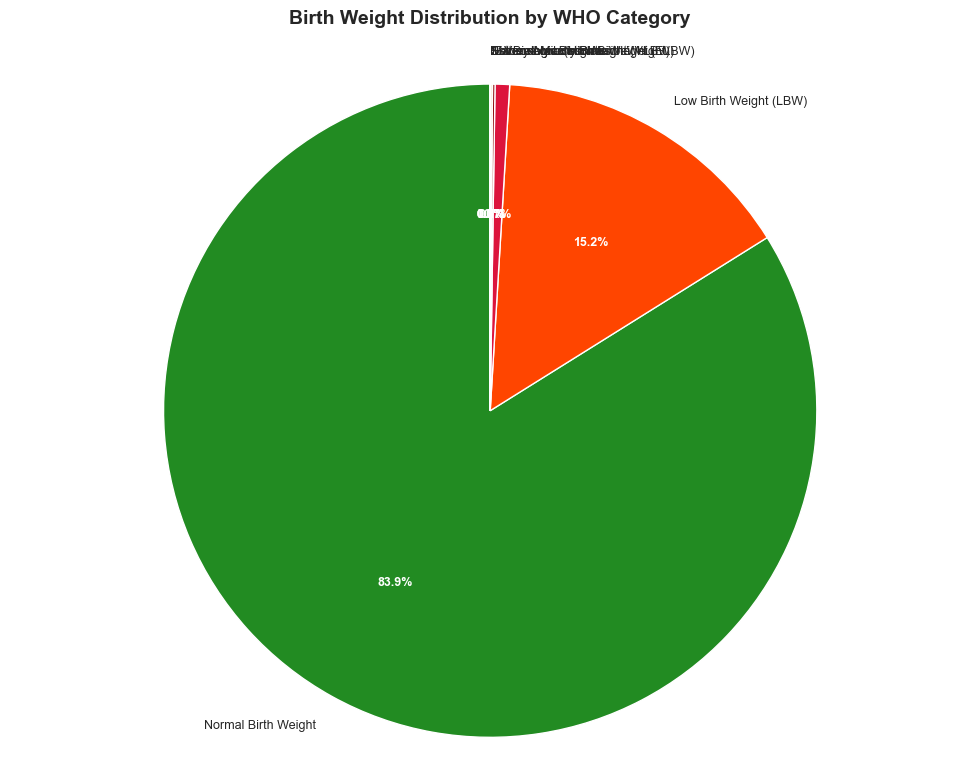

✅ Saved: 3_who_categories_pie.png


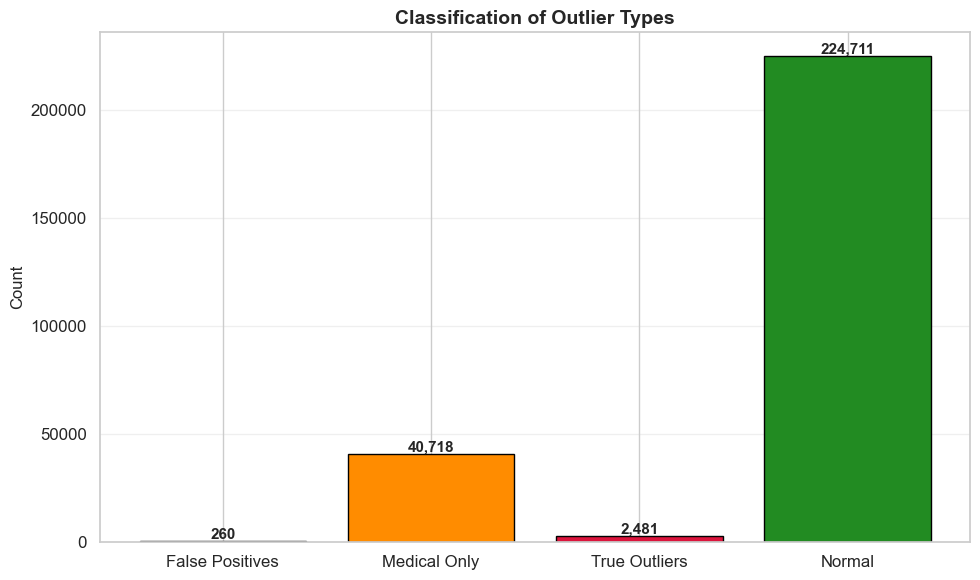

✅ Saved: 4_outlier_types.png


✅ Saved: 5_extreme_values.png


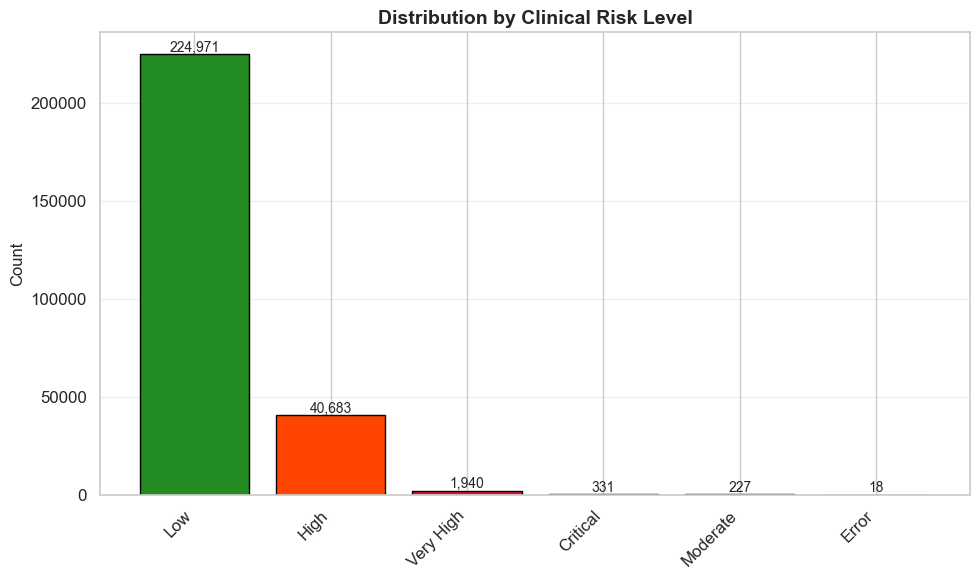

✅ Saved: 6_risk_levels.png


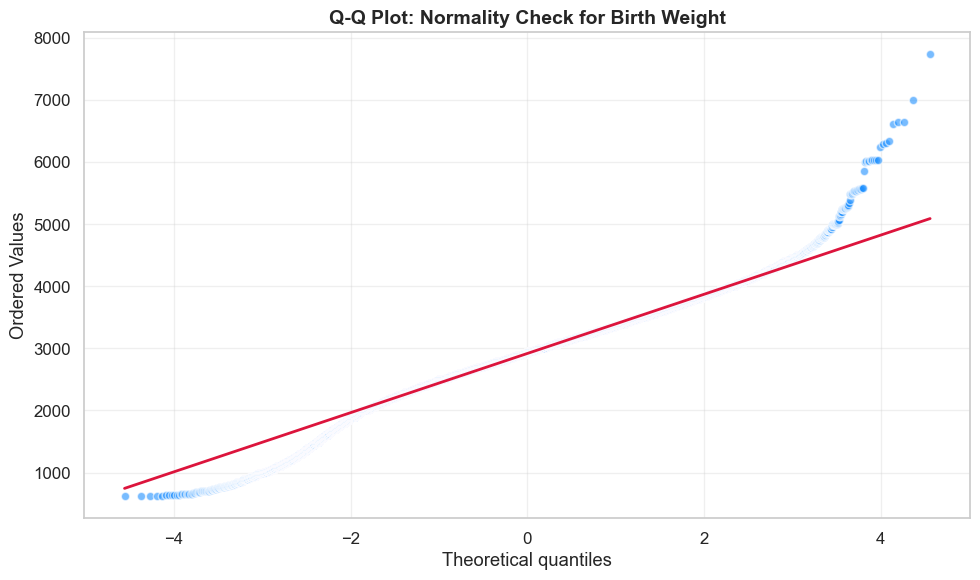

✅ Saved: 7_qq_plot.png

GENERATING TABLES
✅ Saved: table1_stat_methods.csv
✅ Saved: table2_who_summary.csv
✅ Saved: table3_outlier_types.csv
✅ Saved: table4_descriptive_stats.csv
✅ Saved: table5_extreme_values.csv

✅ ALL FILES CREATED SUCCESSFULLY

📊 GRAPHS (7 files):
   1. 1_birth_weight_distribution.png
   2. 2_boxplot_fences.png
   3. 3_who_categories_pie.png
   4. 4_outlier_types.png
   5. 5_extreme_values.png
   6. 6_risk_levels.png
   7. 7_qq_plot.png

📋 TABLES (5 files):
   8. table1_stat_methods.csv
   9. table2_who_summary.csv
   10. table3_outlier_types.csv
   11. table4_descriptive_stats.csv
   12. table5_extreme_values.csv

✅ Total: 12 files generated


In [8]:
# ============================================
# COMPLETE OUTLIER ANALYSIS WITH INDIVIDUAL GRAPHS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD YOUR DATA
# ============================================
print("Loading data...")

# Update this path to your actual file location
file_path = Path("../../../../data/raw/2020_Birth_Final.xlsx")  # Change this path
df = pd.read_excel(file_path)

# Define target variable
TARGET = 'Birth_Weight(grams)'  # Change if needed

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]

print(f"✅ Data loaded: {len(data)} valid records")

# ============================================
# STEP 2: STATISTICAL OUTLIER DETECTION
# ============================================
print("\nCalculating statistical outliers...")

# Method 1: IQR Method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

iqr_outliers = data[(data < lower_fence) | (data > upper_fence)]
extreme_iqr_outliers = data[(data < lower_fence_extreme) | (data > upper_fence_extreme)]

# Method 2: Z-score method
z_scores = np.abs(stats.zscore(data))
z_outliers = data[z_scores > 3]
z_extreme = data[z_scores > 4]

# Method 3: Modified Z-score
median = data.median()
mad = np.median(np.abs(data - median))
if mad > 0:
    modified_z = 0.6745 * (data - median) / mad
else:
    modified_z = np.zeros_like(data)
mod_z_outliers = data[np.abs(modified_z) > 3.5]

print("✅ Statistical calculations complete")

# ============================================
# STEP 3: MEDICAL CLASSIFICATION
# ============================================
print("\nClassifying by WHO categories...")

# Birth weight thresholds (WHO)
medical_thresholds = {
    'Extremely Low Birth Weight (ELBW)': {
        'min': 0, 'max': 999, 
        'color': '#8B0000', 'risk': 'Critical',
        'description': 'Extremely high risk - requires intensive care',
        'action': 'Immediate NICU admission'
    },
    'Very Low Birth Weight (VLBW)': {
        'min': 1000, 'max': 1499, 
        'color': '#DC143C', 'risk': 'Very High',
        'description': 'Very high risk - requires specialized care',
        'action': 'NICU admission required'
    },
    'Low Birth Weight (LBW)': {
        'min': 1500, 'max': 2499, 
        'color': '#FF4500', 'risk': 'High',
        'description': 'Moderate risk - may require monitoring',
        'action': 'Special care nursery'
    },
    'Normal Birth Weight': {
        'min': 2500, 'max': 4499, 
        'color': '#228B22', 'risk': 'Low',
        'description': 'Healthy weight range',
        'action': 'Routine care'
    },
    'Macrosomia (High Birth Weight)': {
        'min': 4500, 'max': 4999, 
        'color': '#FF8C00', 'risk': 'Moderate',
        'description': 'Risk of birth complications',
        'action': 'Monitor for shoulder dystocia'
    },
    'Severe Macrosomia': {
        'min': 5000, 'max': 5499, 
        'color': '#FF1493', 'risk': 'High',
        'description': 'Very high risk of complications',
        'action': 'Prepare for C-section'
    },
    'Extreme Macrosomia': {
        'min': 5500, 'max': 5999, 
        'color': '#800080', 'risk': 'Very High',
        'description': 'Exceptional cases, extremely rare',
        'action': 'Multidisciplinary team required'
    },
    'Not Biologically Plausible': {
        'min': 6000, 'max': float('inf'), 
        'color': '#000000', 'risk': 'Error',
        'description': 'Likely data entry error',
        'action': 'Verify source data'
    }
}

# Create classification DataFrame
classification = []
for value in data:
    for category, details in medical_thresholds.items():
        if details['min'] <= value <= details['max']:
            classification.append({
                'value': value,
                'medical_category': category,
                'risk_level': details['risk'],
                'description': details['description'],
                'action': details['action'],
                'color': details['color']
            })
            break

class_df = pd.DataFrame(classification)

# Add statistical flags
class_df['z_score'] = np.abs(stats.zscore(class_df['value']))
class_df['is_iqr_outlier'] = class_df['value'].isin(iqr_outliers)
class_df['is_extreme_iqr'] = class_df['value'].isin(extreme_iqr_outliers)
class_df['is_z_outlier'] = class_df['value'].isin(z_outliers)
class_df['is_mod_z_outlier'] = class_df['value'].isin(mod_z_outliers)

class_df['methods_count'] = (
    class_df['is_iqr_outlier'].astype(int) + 
    class_df['is_extreme_iqr'].astype(int) + 
    class_df['is_z_outlier'].astype(int) + 
    class_df['is_mod_z_outlier'].astype(int)
)
class_df['is_stat_outlier'] = class_df['methods_count'] >= 2
class_df['is_extreme_stat'] = class_df['is_extreme_iqr'] | (class_df['z_score'] > 4)

print("✅ Classification complete")

# ============================================
# STEP 4: IDENTIFY OUTLIER TYPES
# ============================================
print("\nIdentifying outlier types...")

# Type 1: Statistical outliers that are medically normal
false_positives = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] == 'Normal Birth Weight')
]

# Type 2: Medical outliers that are not statistical outliers
medical_only = class_df[
    (~class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 3: Both statistical and medical outliers
true_outliers = class_df[
    (class_df['is_stat_outlier']) & 
    (class_df['medical_category'] != 'Normal Birth Weight')
]

# Type 4: Extreme low birth weight (<1500g)
extreme_low = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 'Very Low Birth Weight (VLBW)']))
]

# Type 5: Extreme high birth weight (≥5000g)
extreme_high = class_df[
    (class_df['medical_category'].isin(['Severe Macrosomia', 'Extreme Macrosomia']))
]

# Type 6: Biologically implausible values
implausible = class_df[
    (class_df['medical_category'] == 'Not Biologically Plausible') |
    (class_df['value'] < 300)
]

print("✅ Outlier types identified")

# ============================================
# STEP 5: GENERATE INDIVIDUAL GRAPHS
# ============================================
print("\n" + "="*60)
print("GENERATING INDIVIDUAL GRAPHS")
print("="*60)

# Graph 1: Distribution Histogram with WHO Zones
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(data, bins=50, edgecolor='black', alpha=0.7)

for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    if bin_center < 1000:
        patches[i].set_facecolor('#8B0000')
    elif bin_center < 1500:
        patches[i].set_facecolor('#DC143C')
    elif bin_center < 2500:
        patches[i].set_facecolor('#FF4500')
    elif bin_center <= 4499:
        patches[i].set_facecolor('#228B22')
    elif bin_center <= 4999:
        patches[i].set_facecolor('#FF8C00')
    elif bin_center <= 5499:
        patches[i].set_facecolor('#FF1493')
    else:
        patches[i].set_facecolor('#800080')

plt.axvline(x=2500, color='blue', linestyle='--', linewidth=2, label='LBW Threshold (2500g)')
plt.axvline(x=4499, color='red', linestyle='--', linewidth=2, label='Macrosomia Threshold (4499g)')
plt.xlabel('Birth Weight (grams)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Birth Weight Distribution with WHO Classification Zones', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('1_birth_weight_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 1_birth_weight_distribution.png")

# Graph 2: Box Plot with Statistical Fences
plt.figure(figsize=(10, 6))
bp = plt.boxplot(data, patch_artist=True, showfliers=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)
bp['whiskers'][0].set_color('gray')
bp['whiskers'][1].set_color('gray')
bp['caps'][0].set_color('gray')
bp['caps'][1].set_color('gray')
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(2)

plt.axhline(y=lower_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence:.0f}g')
plt.axhline(y=upper_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence:.0f}g')
plt.axhline(y=lower_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme:.0f}g')
plt.axhline(y=upper_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme:.0f}g')

plt.ylabel('Birth Weight (grams)', fontsize=12)
plt.title('Box Plot with Statistical Outlier Fences', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2_boxplot_fences.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 2_boxplot_fences.png")

# Graph 3: Pie Chart - WHO Categories
plt.figure(figsize=(10, 8))
category_counts = class_df['medical_category'].value_counts()
colors = [medical_thresholds[cat]['color'] for cat in category_counts.index]

wedges, texts, autotexts = plt.pie(category_counts.values, 
                                     labels=category_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     startangle=90,
                                     textprops={'fontsize': 9})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Birth Weight Distribution by WHO Category', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig('3_who_categories_pie.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 3_who_categories_pie.png")

# Graph 4: Bar Chart - Outlier Types
plt.figure(figsize=(10, 6))
outlier_types = {
    'False Positives': len(false_positives),
    'Medical Only': len(medical_only),
    'True Outliers': len(true_outliers),
    'Normal': len(data) - len(false_positives) - len(medical_only) - len(true_outliers)
}
colors = ['#1E90FF', '#FF8C00', '#DC143C', '#228B22']
bars = plt.bar(outlier_types.keys(), outlier_types.values(), color=colors, edgecolor='black')

for bar, value in zip(bars, outlier_types.values()):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{value:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Count', fontsize=12)
plt.title('Classification of Outlier Types', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('4_outlier_types.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 4_outlier_types.png")

# Graph 5: Scatter Plot - Extreme Values
plt.figure(figsize=(12, 6))
extreme_values = class_df[
    (class_df['medical_category'].isin(['Extremely Low Birth Weight (ELBW)', 
                                        'Very Low Birth Weight (VLBW)',
                                        'Severe Macrosomia', 
                                        'Extreme Macrosomia',
                                        'Not Biologically Plausible']))
]

if len(extreme_values) > 0:
    colors = [medical_thresholds[cat]['color'] for cat in extreme_values['medical_category']]
    sizes = [100 if 'Extreme' in cat or 'Not' in cat else 70 for cat in extreme_values['medical_category']]
    
    plt.scatter(range(len(extreme_values)), extreme_values['value'], 
                c=colors, s=sizes, alpha=0.7, edgecolor='white', linewidth=1)
    
    plt.axhline(y=2500, color='green', linestyle='--', linewidth=2, label='Normal Range Start (2500g)')
    plt.axhline(y=4499, color='green', linestyle='--', linewidth=2, label='Normal Range End (4499g)')
    plt.axhline(y=1500, color='orange', linestyle=':', linewidth=2, label='VLBW Threshold (1500g)')
    plt.axhline(y=5000, color='red', linestyle=':', linewidth=2, label='Severe Macrosomia (5000g)')
    
    plt.xlabel('Extreme Value Index', fontsize=12)
    plt.ylabel('Birth Weight (grams)', fontsize=12)
    plt.title('Extreme Birth Weight Values', fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    for idx, row in extreme_values.iterrows():
        if row['value'] > 5500 or row['value'] < 800:
            plt.text(idx, row['value'] + 100, f"{row['value']:.0f}g", 
                    fontsize=8, ha='center')

plt.tight_layout()
plt.savefig('5_extreme_values.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 5_extreme_values.png")

# Graph 6: Risk Level Distribution
plt.figure(figsize=(10, 6))
risk_counts = class_df['risk_level'].value_counts()
risk_colors = {
    'Critical': '#8B0000', 
    'Very High': '#DC143C', 
    'High': '#FF4500',
    'Moderate': '#FF8C00', 
    'Low': '#228B22', 
    'Error': '#000000'
}
colors = [risk_colors.get(risk, 'gray') for risk in risk_counts.index]

bars = plt.bar(range(len(risk_counts)), risk_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(risk_counts)), risk_counts.index, rotation=45, ha='right')
plt.ylabel('Count', fontsize=12)
plt.title('Distribution by Clinical Risk Level', fontsize=14, fontweight='bold')

for bar, count in zip(bars, risk_counts.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('6_risk_levels.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 6_risk_levels.png")

# Graph 7: Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(data, dist="norm", plot=plt)
plt.gca().get_lines()[0].set_markerfacecolor('#1E90FF')
plt.gca().get_lines()[0].set_markeredgecolor('white')
plt.gca().get_lines()[0].set_alpha(0.6)
plt.gca().get_lines()[1].set_color('#DC143C')
plt.gca().get_lines()[1].set_linewidth(2)
plt.title('Q-Q Plot: Normality Check for Birth Weight', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('7_qq_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 7_qq_plot.png")

# ============================================
# STEP 6: GENERATE TABLES
# ============================================
print("\n" + "="*60)
print("GENERATING TABLES")
print("="*60)

# Table 1: Statistical Methods Comparison
comparison_data = {
    'Method': ['IQR (1.5x)', 'Extreme IQR (3x)', 'Z-score (>3)', 'Modified Z-score', 'Consensus'],
    'Outliers Count': [
        len(iqr_outliers),
        len(extreme_iqr_outliers),
        len(z_outliers),
        len(mod_z_outliers),
        len(class_df[class_df['is_stat_outlier']])
    ],
    'Percentage': [
        f"{len(iqr_outliers)/len(data)*100:.2f}%",
        f"{len(extreme_iqr_outliers)/len(data)*100:.2f}%",
        f"{len(z_outliers)/len(data)*100:.2f}%",
        f"{len(mod_z_outliers)/len(data)*100:.2f}%",
        f"{len(class_df[class_df['is_stat_outlier']])/len(data)*100:.2f}%"
    ]
}
comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('table1_stat_methods.csv', index=False)
print("✅ Saved: table1_stat_methods.csv")

# Table 2: WHO Categories Summary
who_table = class_df.groupby(['medical_category', 'risk_level']).agg({
    'value': ['count', 'mean', 'min', 'max'],
    'is_stat_outlier': 'sum'
}).round(1)
who_table.columns = ['Count', 'Mean (g)', 'Min (g)', 'Max (g)', 'Statistical Outliers']
who_table = who_table.reset_index()
who_table.to_csv('table2_who_summary.csv', index=False)
print("✅ Saved: table2_who_summary.csv")

# Table 3: Outlier Types Details
outlier_details = pd.DataFrame({
    'Outlier Type': ['False Positives', 'Medical Only', 'True Outliers', 'Extreme Low', 'Extreme High', 'Implausible'],
    'Count': [
        len(false_positives),
        len(medical_only),
        len(true_outliers),
        len(extreme_low),
        len(extreme_high),
        len(implausible)
    ],
    'Percentage': [
        f"{len(false_positives)/len(data)*100:.2f}%",
        f"{len(medical_only)/len(data)*100:.2f}%",
        f"{len(true_outliers)/len(data)*100:.2f}%",
        f"{len(extreme_low)/len(data)*100:.2f}%",
        f"{len(extreme_high)/len(data)*100:.2f}%",
        f"{len(implausible)/len(data)*100:.2f}%"
    ],
    'Description': [
        'Statistical outliers but medically normal',
        'Medically abnormal but not statistical outliers',
        'Both statistical and medical outliers',
        'Very low birth weight (<1500g)',
        'Very high birth weight (≥5000g)',
        'Biologically impossible values'
    ]
})
outlier_details.to_csv('table3_outlier_types.csv', index=False)
print("✅ Saved: table3_outlier_types.csv")

# Table 4: Descriptive Statistics
stats_table = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Median', 'Mode', 'Std Dev', 'Min', 'Max', 'Range', 'Q1', 'Q3', 'IQR', 'Skewness'],
    'Value': [
        len(data),
        f"{data.mean():.1f}",
        f"{data.median():.1f}",
        f"{data.mode().values[0]:.1f}" if len(data.mode()) > 0 else 'N/A',
        f"{data.std():.1f}",
        f"{data.min():.1f}",
        f"{data.max():.1f}",
        f"{data.max() - data.min():.1f}",
        f"{Q1:.1f}",
        f"{Q3:.1f}",
        f"{IQR:.1f}",
        f"{data.skew():.3f}"
    ]
})
stats_table.to_csv('table4_descriptive_stats.csv', index=False)
print("✅ Saved: table4_descriptive_stats.csv")

# Table 5: Extreme Values List
if len(extreme_values) > 0:
    extreme_list = extreme_values[['value', 'medical_category', 'risk_level', 'z_score']].copy()
    extreme_list = extreme_list.sort_values('value', ascending=False)
    extreme_list['z_score'] = extreme_list['z_score'].round(2)
    extreme_list.to_csv('table5_extreme_values.csv', index=False)
    print("✅ Saved: table5_extreme_values.csv")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("✅ ALL FILES CREATED SUCCESSFULLY")
print("="*60)
print("\n📊 GRAPHS (7 files):")
print("   1. 1_birth_weight_distribution.png")
print("   2. 2_boxplot_fences.png")
print("   3. 3_who_categories_pie.png")
print("   4. 4_outlier_types.png")
print("   5. 5_extreme_values.png")
print("   6. 6_risk_levels.png")
print("   7. 7_qq_plot.png")

print("\n📋 TABLES (5 files):")
print("   8. table1_stat_methods.csv")
print("   9. table2_who_summary.csv")
print("   10. table3_outlier_types.csv")
print("   11. table4_descriptive_stats.csv")
print("   12. table5_extreme_values.csv")

print("\n✅ Total: 12 files generated")
print("="*60)

🔍 FINAL OUTLIER VALIDATION: POSSIBLE VS IMPOSSIBLE

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Range: 620 - 7740g

────────────────────────────────────────────────────────────────────────────────
🏥 STEP 2: DEFINING MEDICAL POSSIBILITY CRITERIA
────────────────────────────────────────────────────────────────────────────────

📋 Medical Possibility Classification:
   • Impossible - Data Error: 6,000 - ∞g
     Reason: Biologically impossible, likely data error
     Action: MUST REMOVE - Data entry error
   • Extremely Rare - Borderline Viable: 300 - 499g
     Reason: Extremely rare, only few documented cases worldwide
     Action: VERIFY with medical records
   • Extremely Low Birth Weight (ELBW) - Possible: 500 - 999g
     Reason: Possible with intensive care, though high mortality
     Action: Valid medical outliers - KEEP
   • Very Low Birth Weight (VLBW) - Possible: 1,000 - 1,499g
     Reason: Possible, requires NICU care
     Action: Valid medical

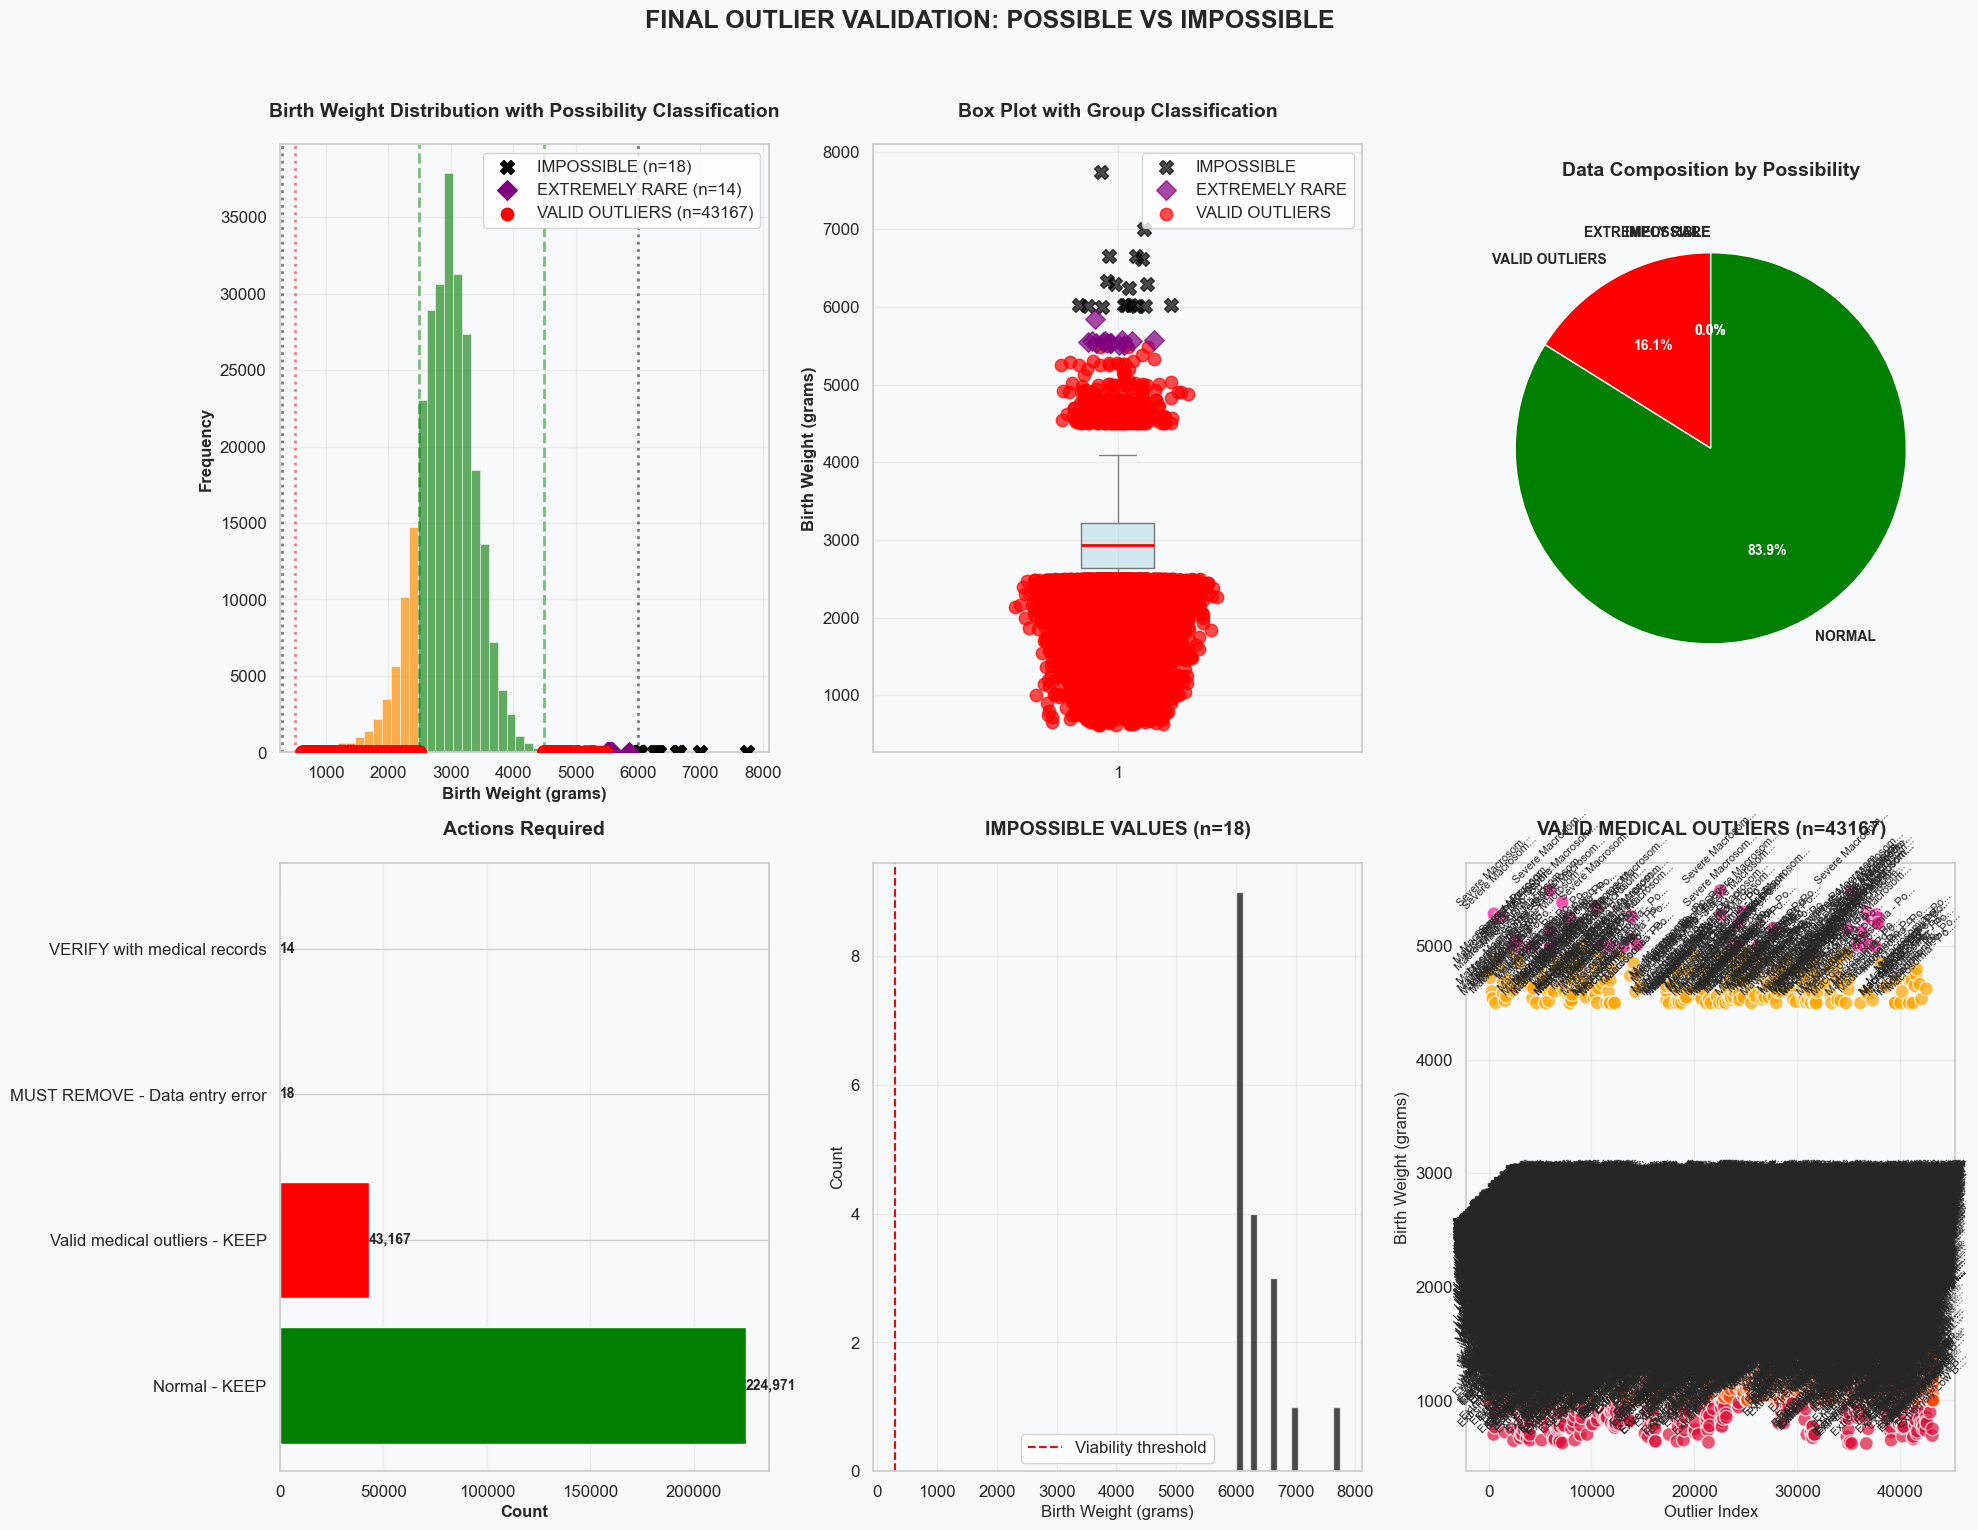

✅ Saved: final_outlier_validation.png

────────────────────────────────────────────────────────────────────────────────
📁 STEP 6: CREATING DETAILED EXCEL REPORT
────────────────────────────────────────────────────────────────────────────────
✅ Excel report saved: final_outlier_validation_report.xlsx

────────────────────────────────────────────────────────────────────────────────
📋 STEP 7: FINAL RECOMMENDATIONS
────────────────────────────────────────────────────────────────────────────────

🎯 FINAL OUTLIER VALIDATION RESULTS

📊 SUMMARY STATISTICS:
   • Total records analyzed: 268,170
   • Statistical outliers (IQR): 6,522

❌ IMPOSSIBLE VALUES - MUST REMOVE:
   • Count: 18
   • Range: 6000 - 7740g
   • These are data entry errors and should be removed

   List of impossible values:
      • 6300g - N/A
      • 6332g - N/A
      • 6030g - N/A
      • 6026g - N/A
      • 6000g - N/A
      • 7740g - N/A
      • 6620g - N/A
      • 6026g - N/A
      • 6293g - N/A
      • 6013g - N/A
      •

In [9]:
# ============================================
# FINAL STEP: VALIDATE OUTLIERS - POSSIBLE VS IMPOSSIBLE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD YOUR DATA
# ============================================
print("="*80)
print("🔍 FINAL OUTLIER VALIDATION: POSSIBLE VS IMPOSSIBLE")
print("="*80)

# Update this path to your actual file location
file_path = Path("../../../../data/raw/2020_Birth_Final.xlsx")  # Change this path
df = pd.read_excel(file_path)

# Define target variable
TARGET = 'Birth_Weight(grams)'  # Change if needed

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Range: {data.min():.0f} - {data.max():.0f}g")

# ============================================
# STEP 2: DEFINE MEDICAL POSSIBILITY CRITERIA
# ============================================
print(f"\n{'─'*80}")
print("🏥 STEP 2: DEFINING MEDICAL POSSIBILITY CRITERIA")
print('─'*80)

# WHO and Medical Literature Based Criteria
medical_possibility = {
    'Impossible - Data Error': {
        'range': [0, 299],
        'color': '#000000',
        'reason': 'Biologically impossible for live birth',
        'action': 'MUST REMOVE - Data entry error'
    },
    'Extremely Rare - Borderline Viable': {
        'range': [300, 499],
        'color': '#8B0000',
        'reason': 'Extremely rare, only few documented cases worldwide',
        'action': 'VERIFY with medical records'
    },
    'Extremely Low Birth Weight (ELBW) - Possible': {
        'range': [500, 999],
        'color': '#DC143C',
        'reason': 'Possible with intensive care, though high mortality',
        'action': 'Valid medical outliers - KEEP'
    },
    'Very Low Birth Weight (VLBW) - Possible': {
        'range': [1000, 1499],
        'color': '#FF4500',
        'reason': 'Possible, requires NICU care',
        'action': 'Valid medical outliers - KEEP'
    },
    'Low Birth Weight (LBW) - Possible': {
        'range': [1500, 2499],
        'color': '#FF8C00',
        'reason': 'Common, may require monitoring',
        'action': 'Valid medical outliers - KEEP'
    },
    'Normal Birth Weight': {
        'range': [2500, 4499],
        'color': '#228B22',
        'reason': 'Normal healthy range',
        'action': 'Normal - KEEP'
    },
    'Macrosomia - Possible': {
        'range': [4500, 4999],
        'color': '#FFA500',
        'reason': 'Possible, risk of birth complications',
        'action': 'Valid medical outliers - KEEP'
    },
    'Severe Macrosomia - Rare but Possible': {
        'range': [5000, 5499],
        'color': '#FF1493',
        'reason': 'Rare but documented, very high risk',
        'action': 'Valid medical outliers - KEEP'
    },
    'Extreme Macrosomia - Extremely Rare': {
        'range': [5500, 5999],
        'color': '#800080',
        'reason': 'Extremely rare, exceptional cases',
        'action': 'VERIFY with medical records'
    },
    'Impossible - Data Error': {
        'range': [6000, float('inf')],
        'color': '#000000',
        'reason': 'Biologically impossible, likely data error',
        'action': 'MUST REMOVE - Data entry error'
    }
}

print("\n📋 Medical Possibility Classification:")
for category, details in medical_possibility.items():
    max_val = '∞' if details['range'][1] == float('inf') else f"{details['range'][1]:,}"
    print(f"   • {category}: {details['range'][0]:,} - {max_val}g")
    print(f"     Reason: {details['reason']}")
    print(f"     Action: {details['action']}")

# ============================================
# STEP 3: CLASSIFY EACH RECORD
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 3: CLASSIFYING ALL RECORDS")
print('─'*80)

# Create classification DataFrame with all variables
classification = []
for idx, value in data.items():
    for category, details in medical_possibility.items():
        if details['range'][0] <= value <= details['range'][1]:
            # Get the original row data
            original_row = df.loc[idx].to_dict()
            
            record = {
                'index': idx,
                'birth_weight': value,
                'possibility_category': category,
                'reason': details['reason'],
                'action': details['action'],
                'color': details['color']
            }
            
            # Add all other variables from the original dataframe
            for col in df.columns:
                if col != TARGET:
                    record[col] = original_row.get(col, 'N/A')
            
            classification.append(record)
            break

class_df = pd.DataFrame(classification)

# Add statistical outlier flags
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

class_df['is_statistical_outlier'] = (
    (class_df['birth_weight'] < lower_fence) | 
    (class_df['birth_weight'] > upper_fence)
)

class_df['z_score'] = np.abs(stats.zscore(class_df['birth_weight']))

# Summary by possibility category
possibility_summary = class_df.groupby(['possibility_category', 'action']).agg({
    'birth_weight': ['count', 'mean', 'min', 'max'],
    'is_statistical_outlier': 'sum'
}).round(1)

possibility_summary.columns = ['Count', 'Mean', 'Min', 'Max', 'Stat_Outliers']
possibility_summary = possibility_summary.reset_index()

print("\n📈 CLASSIFICATION SUMMARY:")
for _, row in possibility_summary.iterrows():
    pct = (row['Count'] / len(data) * 100)
    print(f"\n   {row['possibility_category']}:")
    print(f"      • Count: {row['Count']:,} ({pct:.1f}%)")
    print(f"      • Range: {row['Min']:.0f} - {row['Max']:.0f}g")
    print(f"      • Statistical outliers in this group: {row['Stat_Outliers']}")

# ============================================
# STEP 4: IDENTIFY KEY GROUPS
# ============================================
print(f"\n{'─'*80}")
print("🎯 STEP 4: IDENTIFYING KEY GROUPS")
print('─'*80)

# Group 1: IMPOSSIBLE VALUES - Must be removed
impossible_values = class_df[
    class_df['action'].str.contains('MUST REMOVE')
]

# Group 2: EXTREMELY RARE - Needs verification
rare_values = class_df[
    class_df['action'].str.contains('VERIFY')
]

# Group 3: VALID MEDICAL OUTLIERS - Keep for analysis
valid_outliers = class_df[
    (class_df['action'].str.contains('KEEP')) & 
    (class_df['possibility_category'] != 'Normal Birth Weight')
]

# Group 4: NORMAL VALUES
normal_values = class_df[
    class_df['possibility_category'] == 'Normal Birth Weight'
]

print(f"\n📊 KEY GROUPS IDENTIFIED:")
print(f"\n   ❌ IMPOSSIBLE VALUES (MUST REMOVE):")
print(f"      • Count: {len(impossible_values):,}")
if len(impossible_values) > 0:
    print(f"      • Range: {impossible_values['birth_weight'].min():.0f} - {impossible_values['birth_weight'].max():.0f}g")
    print(f"      • These are data entry errors")

print(f"\n   ⚠️ EXTREMELY RARE (NEEDS VERIFICATION):")
print(f"      • Count: {len(rare_values):,}")
if len(rare_values) > 0:
    print(f"      • Range: {rare_values['birth_weight'].min():.0f} - {rare_values['birth_weight'].max():.0f}g")
    print(f"      • These need medical record verification")

print(f"\n   ✅ VALID MEDICAL OUTLIERS (KEEP):")
print(f"      • Count: {len(valid_outliers):,}")
if len(valid_outliers) > 0:
    print(f"      • Categories:")
    for cat in valid_outliers['possibility_category'].unique():
        cat_count = len(valid_outliers[valid_outliers['possibility_category'] == cat])
        print(f"         - {cat}: {cat_count}")

print(f"\n   📊 NORMAL VALUES:")
print(f"      • Count: {len(normal_values):,}")

# ============================================
# STEP 5: CLEAR VISUALIZATION
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 5: CREATING CLEAR VISUALIZATION")
print('─'*80)

# Create a comprehensive figure
fig = plt.figure(figsize=(20, 15))
fig.patch.set_facecolor('#f8f9fa')

# 1. Main Distribution with Clear Grouping
ax1 = plt.subplot(2, 3, 1)
ax1.set_facecolor('#f8f9fa')

# Create histogram with clear grouping
n, bins, patches = ax1.hist(data, bins=50, edgecolor='white', linewidth=0.5, alpha=0.7)

# Color by possibility
for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    for category, details in medical_possibility.items():
        if details['range'][0] <= bin_center <= details['range'][1]:
            patches[i].set_facecolor(details['color'])
            patches[i].set_alpha(0.7)
            break

# Highlight different groups with markers
if len(impossible_values) > 0:
    ax1.scatter(impossible_values['birth_weight'], 
               [5]*len(impossible_values), 
               color='black', marker='X', s=100, 
               label=f'IMPOSSIBLE (n={len(impossible_values)})', zorder=5)

if len(rare_values) > 0:
    ax1.scatter(rare_values['birth_weight'], 
               [10]*len(rare_values), 
               color='purple', marker='D', s=100, 
               label=f'EXTREMELY RARE (n={len(rare_values)})', zorder=5)

if len(valid_outliers) > 0:
    ax1.scatter(valid_outliers['birth_weight'], 
               [15]*len(valid_outliers), 
               color='red', marker='o', s=80, 
               label=f'VALID OUTLIERS (n={len(valid_outliers)})', zorder=5)

ax1.set_xlabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Birth Weight Distribution with Possibility Classification', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)

# Add threshold lines
ax1.axvline(x=300, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax1.axvline(x=500, color='red', linestyle=':', linewidth=2, alpha=0.5)
ax1.axvline(x=2500, color='green', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=4499, color='green', linestyle='--', linewidth=2, alpha=0.5)
ax1.axvline(x=6000, color='black', linestyle=':', linewidth=2, alpha=0.5)

# 2. Box Plot with Group Highlighting
ax2 = plt.subplot(2, 3, 2)
ax2.set_facecolor('#f8f9fa')

bp = ax2.boxplot(data, patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.5)
bp['whiskers'][0].set_color('gray')
bp['whiskers'][1].set_color('gray')
bp['caps'][0].set_color('gray')
bp['caps'][1].set_color('gray')
bp['medians'][0].set_color('red')
bp['medians'][0].set_linewidth(2)

# Add jittered scatter for each group
if len(impossible_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(impossible_values))], 
               impossible_values['birth_weight'], 
               color='black', alpha=0.7, marker='X', s=100,
               label='IMPOSSIBLE', zorder=5)

if len(rare_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(rare_values))], 
               rare_values['birth_weight'], 
               color='purple', alpha=0.7, marker='D', s=100,
               label='EXTREMELY RARE', zorder=5)

if len(valid_outliers) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(valid_outliers))], 
               valid_outliers['birth_weight'], 
               color='red', alpha=0.7, s=80,
               label='VALID OUTLIERS', zorder=4)

ax2.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax2.set_title('Box Plot with Group Classification', 
             fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='best', frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)

# 3. Group Composition Pie Chart
ax3 = plt.subplot(2, 3, 3)
ax3.set_facecolor('#f8f9fa')

group_sizes = [
    len(impossible_values),
    len(rare_values),
    len(valid_outliers),
    len(normal_values)
]
group_labels = ['IMPOSSIBLE', 'EXTREMELY RARE', 'VALID OUTLIERS', 'NORMAL']
group_colors = ['black', 'purple', 'red', 'green']

wedges, texts, autotexts = ax3.pie(group_sizes, 
                                    labels=group_labels,
                                    autopct='%1.1f%%',
                                    colors=group_colors,
                                    startangle=90,
                                    textprops={'fontsize': 10, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax3.set_title('Data Composition by Possibility', fontsize=14, fontweight='bold', pad=20)

# 4. Action Required Bar Chart
ax4 = plt.subplot(2, 3, 4)
ax4.set_facecolor('#f8f9fa')

action_counts = class_df['action'].value_counts()
action_colors = {
    'MUST REMOVE - Data entry error': 'black',
    'VERIFY with medical records': 'purple',
    'Valid medical outliers - KEEP': 'red',
    'Normal - KEEP': 'green'
}
colors = [action_colors.get(action, 'gray') for action in action_counts.index]

bars = ax4.barh(range(len(action_counts)), action_counts.values, color=colors, edgecolor='white')
ax4.set_yticks(range(len(action_counts)))
ax4.set_yticklabels([a[:30] + '...' if len(a) > 30 else a for a in action_counts.index])
ax4.set_xlabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Actions Required', fontsize=14, fontweight='bold', pad=20)

for bar, count in zip(bars, action_counts.values):
    ax4.text(count + 1, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax4.grid(True, alpha=0.3, axis='x')

# 5. Impossible Values Distribution
ax5 = plt.subplot(2, 3, 5)
ax5.set_facecolor('#f8f9fa')

if len(impossible_values) > 0:
    ax5.hist(impossible_values['birth_weight'], bins=15, color='black', alpha=0.7, edgecolor='white')
    ax5.set_xlabel('Birth Weight (grams)', fontsize=12)
    ax5.set_ylabel('Count', fontsize=12)
    ax5.set_title(f'IMPOSSIBLE VALUES (n={len(impossible_values)})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax5.axvline(x=300, color='red', linestyle='--', label='Viability threshold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'NO IMPOSSIBLE VALUES FOUND', 
            ha='center', va='center', fontsize=14, fontweight='bold')
    ax5.set_title('Impossible Values', fontsize=14, fontweight='bold')

# 6. Valid Outliers Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.set_facecolor('#f8f9fa')

if len(valid_outliers) > 0:
    colors = [medical_possibility[cat]['color'] for cat in valid_outliers['possibility_category']]
    scatter = ax6.scatter(range(len(valid_outliers)), valid_outliers['birth_weight'], 
                         c=colors, s=100, alpha=0.7, edgecolor='white')
    
    # Add category labels
    for i, (idx, row) in enumerate(valid_outliers.iterrows()):
        ax6.text(i, row['birth_weight'] + 50, row['possibility_category'][:15] + '...', 
                ha='center', va='bottom', fontsize=8, rotation=45)
    
    ax6.set_xlabel('Outlier Index', fontsize=12)
    ax6.set_ylabel('Birth Weight (grams)', fontsize=12)
    ax6.set_title(f'VALID MEDICAL OUTLIERS (n={len(valid_outliers)})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'NO VALID OUTLIERS FOUND', 
            ha='center', va='center', fontsize=14, fontweight='bold')
    ax6.set_title('Valid Medical Outliers', fontsize=14, fontweight='bold')

plt.suptitle('FINAL OUTLIER VALIDATION: POSSIBLE VS IMPOSSIBLE', 
            fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('final_outlier_validation.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: final_outlier_validation.png")

# ============================================
# STEP 6: CREATE DETAILED EXCEL REPORT
# ============================================
print(f"\n{'─'*80}")
print("📁 STEP 6: CREATING DETAILED EXCEL REPORT")
print('─'*80)

excel_filename = 'final_outlier_validation_report.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    
    # Sheet 1: Executive Summary
    summary_data = {
        'Category': ['Total Records', 'Valid Records', 'IMPOSSIBLE (Remove)', 'EXTREMELY RARE (Verify)', 
                     'VALID OUTLIERS (Keep)', 'NORMAL (Keep)'],
        'Count': [
            len(original_data),
            len(data),
            len(impossible_values),
            len(rare_values),
            len(valid_outliers),
            len(normal_values)
        ],
        'Percentage': [
            100.0,
            100.0,
            (len(impossible_values)/len(data)*100),
            (len(rare_values)/len(data)*100),
            (len(valid_outliers)/len(data)*100),
            (len(normal_values)/len(data)*100)
        ],
        'Action': [
            '-',
            '-',
            'MUST REMOVE - Data entry error',
            'Verify with medical records',
            'Keep for analysis',
            'Keep as normal'
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Executive_Summary', index=False)
    
    # Sheet 2: ALL IMPOSSIBLE VALUES (MUST REMOVE)
    if len(impossible_values) > 0:
        impossible_values.to_excel(writer, sheet_name='IMPOSSIBLE_Values_Remove', index=False)
    
    # Sheet 3: EXTREMELY RARE (Need Verification)
    if len(rare_values) > 0:
        rare_values.to_excel(writer, sheet_name='EXTREMELY_RARE_Verify', index=False)
    
    # Sheet 4: VALID MEDICAL OUTLIERS (Keep)
    if len(valid_outliers) > 0:
        valid_outliers.to_excel(writer, sheet_name='VALID_Outliers_Keep', index=False)
    
    # Sheet 5: NORMAL VALUES
    if len(normal_values) > 0:
        normal_values.to_excel(writer, sheet_name='NORMAL_Values', index=False)
    
    # Sheet 6: Complete Dataset with Classification
    class_df.to_excel(writer, sheet_name='Complete_Dataset', index=False)
    
    # Sheet 7: Summary by Category
    summary_by_cat = class_df.groupby('possibility_category').agg({
        'birth_weight': ['count', 'mean', 'min', 'max', 'std'],
        'is_statistical_outlier': 'sum'
    }).round(1)
    summary_by_cat.columns = ['Count', 'Mean', 'Min', 'Max', 'Std', 'Statistical_Outliers']
    summary_by_cat.to_excel(writer, sheet_name='Category_Summary')
    
    # Sheet 8: Statistical Summary
    stats_df = pd.DataFrame({
        'Metric': ['Q1', 'Median', 'Q3', 'IQR', 'Lower Fence', 'Upper Fence'],
        'Value': [Q1, data.median(), Q3, IQR, lower_fence, upper_fence]
    })
    stats_df.to_excel(writer, sheet_name='Statistical_Summary', index=False)

print(f"✅ Excel report saved: {excel_filename}")

# ============================================
# STEP 7: FINAL RECOMMENDATIONS
# ============================================
print(f"\n{'─'*80}")
print("📋 STEP 7: FINAL RECOMMENDATIONS")
print('─'*80)

print(f"\n{'='*80}")
print("🎯 FINAL OUTLIER VALIDATION RESULTS")
print('='*80)

print(f"\n📊 SUMMARY STATISTICS:")
print(f"   • Total records analyzed: {len(data):,}")
print(f"   • Statistical outliers (IQR): {len(class_df[class_df['is_statistical_outlier']]):,}")

print(f"\n❌ IMPOSSIBLE VALUES - MUST REMOVE:")
if len(impossible_values) > 0:
    print(f"   • Count: {len(impossible_values):,}")
    print(f"   • Range: {impossible_values['birth_weight'].min():.0f} - {impossible_values['birth_weight'].max():.0f}g")
    print(f"   • These are data entry errors and should be removed")
    print(f"\n   List of impossible values:")
    for _, row in impossible_values.iterrows():
        print(f"      • {row['birth_weight']:.0f}g - {row.get('Patient_ID', 'N/A')}")

print(f"\n⚠️ EXTREMELY RARE - NEEDS VERIFICATION:")
if len(rare_values) > 0:
    print(f"   • Count: {len(rare_values):,}")
    print(f"   • Range: {rare_values['birth_weight'].min():.0f} - {rare_values['birth_weight'].max():.0f}g")
    print(f"   • These need medical record verification")

print(f"\n✅ VALID MEDICAL OUTLIERS - KEEP FOR ANALYSIS:")
if len(valid_outliers) > 0:
    print(f"   • Count: {len(valid_outliers):,}")
    print(f"   • Categories represented:")
    for cat in valid_outliers['possibility_category'].unique():
        cat_count = len(valid_outliers[valid_outliers['possibility_category'] == cat])
        print(f"      - {cat}: {cat_count}")

print(f"\n📊 NORMAL VALUES - KEEP:")
print(f"   • Count: {len(normal_values):,}")

print(f"\n{'='*80}")
print("📋 FINAL RECOMMENDATIONS:")
print('='*80)
print(f"\n1. ❌ REMOVE {len(impossible_values):,} records (biologically impossible)")
print(f"2. ⚠️ VERIFY {len(rare_values):,} records with medical records")
print(f"3. ✅ KEEP {len(valid_outliers):,} valid medical outliers for analysis")
print(f"4. 📊 PROCEED with analysis including {len(valid_outliers) + len(normal_values):,} valid records")

print(f"\n📁 FILES CREATED:")
print(f"   • PNG: final_outlier_validation.png")
print(f"   • Excel: {excel_filename}")

print(f"\n{'='*80}")
print("✅ FINAL OUTLIER VALIDATION COMPLETE")
print('='*80)

🔍 FINAL OUTLIER VALIDATION: POSSIBLE VS IMPOSSIBLE

📌 DATASET OVERVIEW:
   • Total records: 301,712
   • Valid records: 268,170
   • Range: 620 - 7740g

────────────────────────────────────────────────────────────────────────────────
📊 STEP 2: CALCULATING STATISTICAL PARAMETERS
────────────────────────────────────────────────────────────────────────────────

📈 STATISTICAL SUMMARY:
   • Mean: 2917.7g
   • Median: 2930.0g
   • Q1 (25th): 2640.0g
   • Q3 (75th): 3220.0g
   • IQR: 580.0g
   • Lower Fence (1.5*IQR): 1770.0g
   • Upper Fence (1.5*IQR): 4090.0g
   • Extreme Lower (3*IQR): 900.0g
   • Extreme Upper (3*IQR): 4960.0g

────────────────────────────────────────────────────────────────────────────────
🏥 STEP 3: DEFINING MEDICAL POSSIBILITY CRITERIA
────────────────────────────────────────────────────────────────────────────────

📋 Medical Possibility Classification:
   • Impossible - Data Error: 6,000 - ∞g
     Reason: Biologically impossible, likely data error
     Action: MUST REM

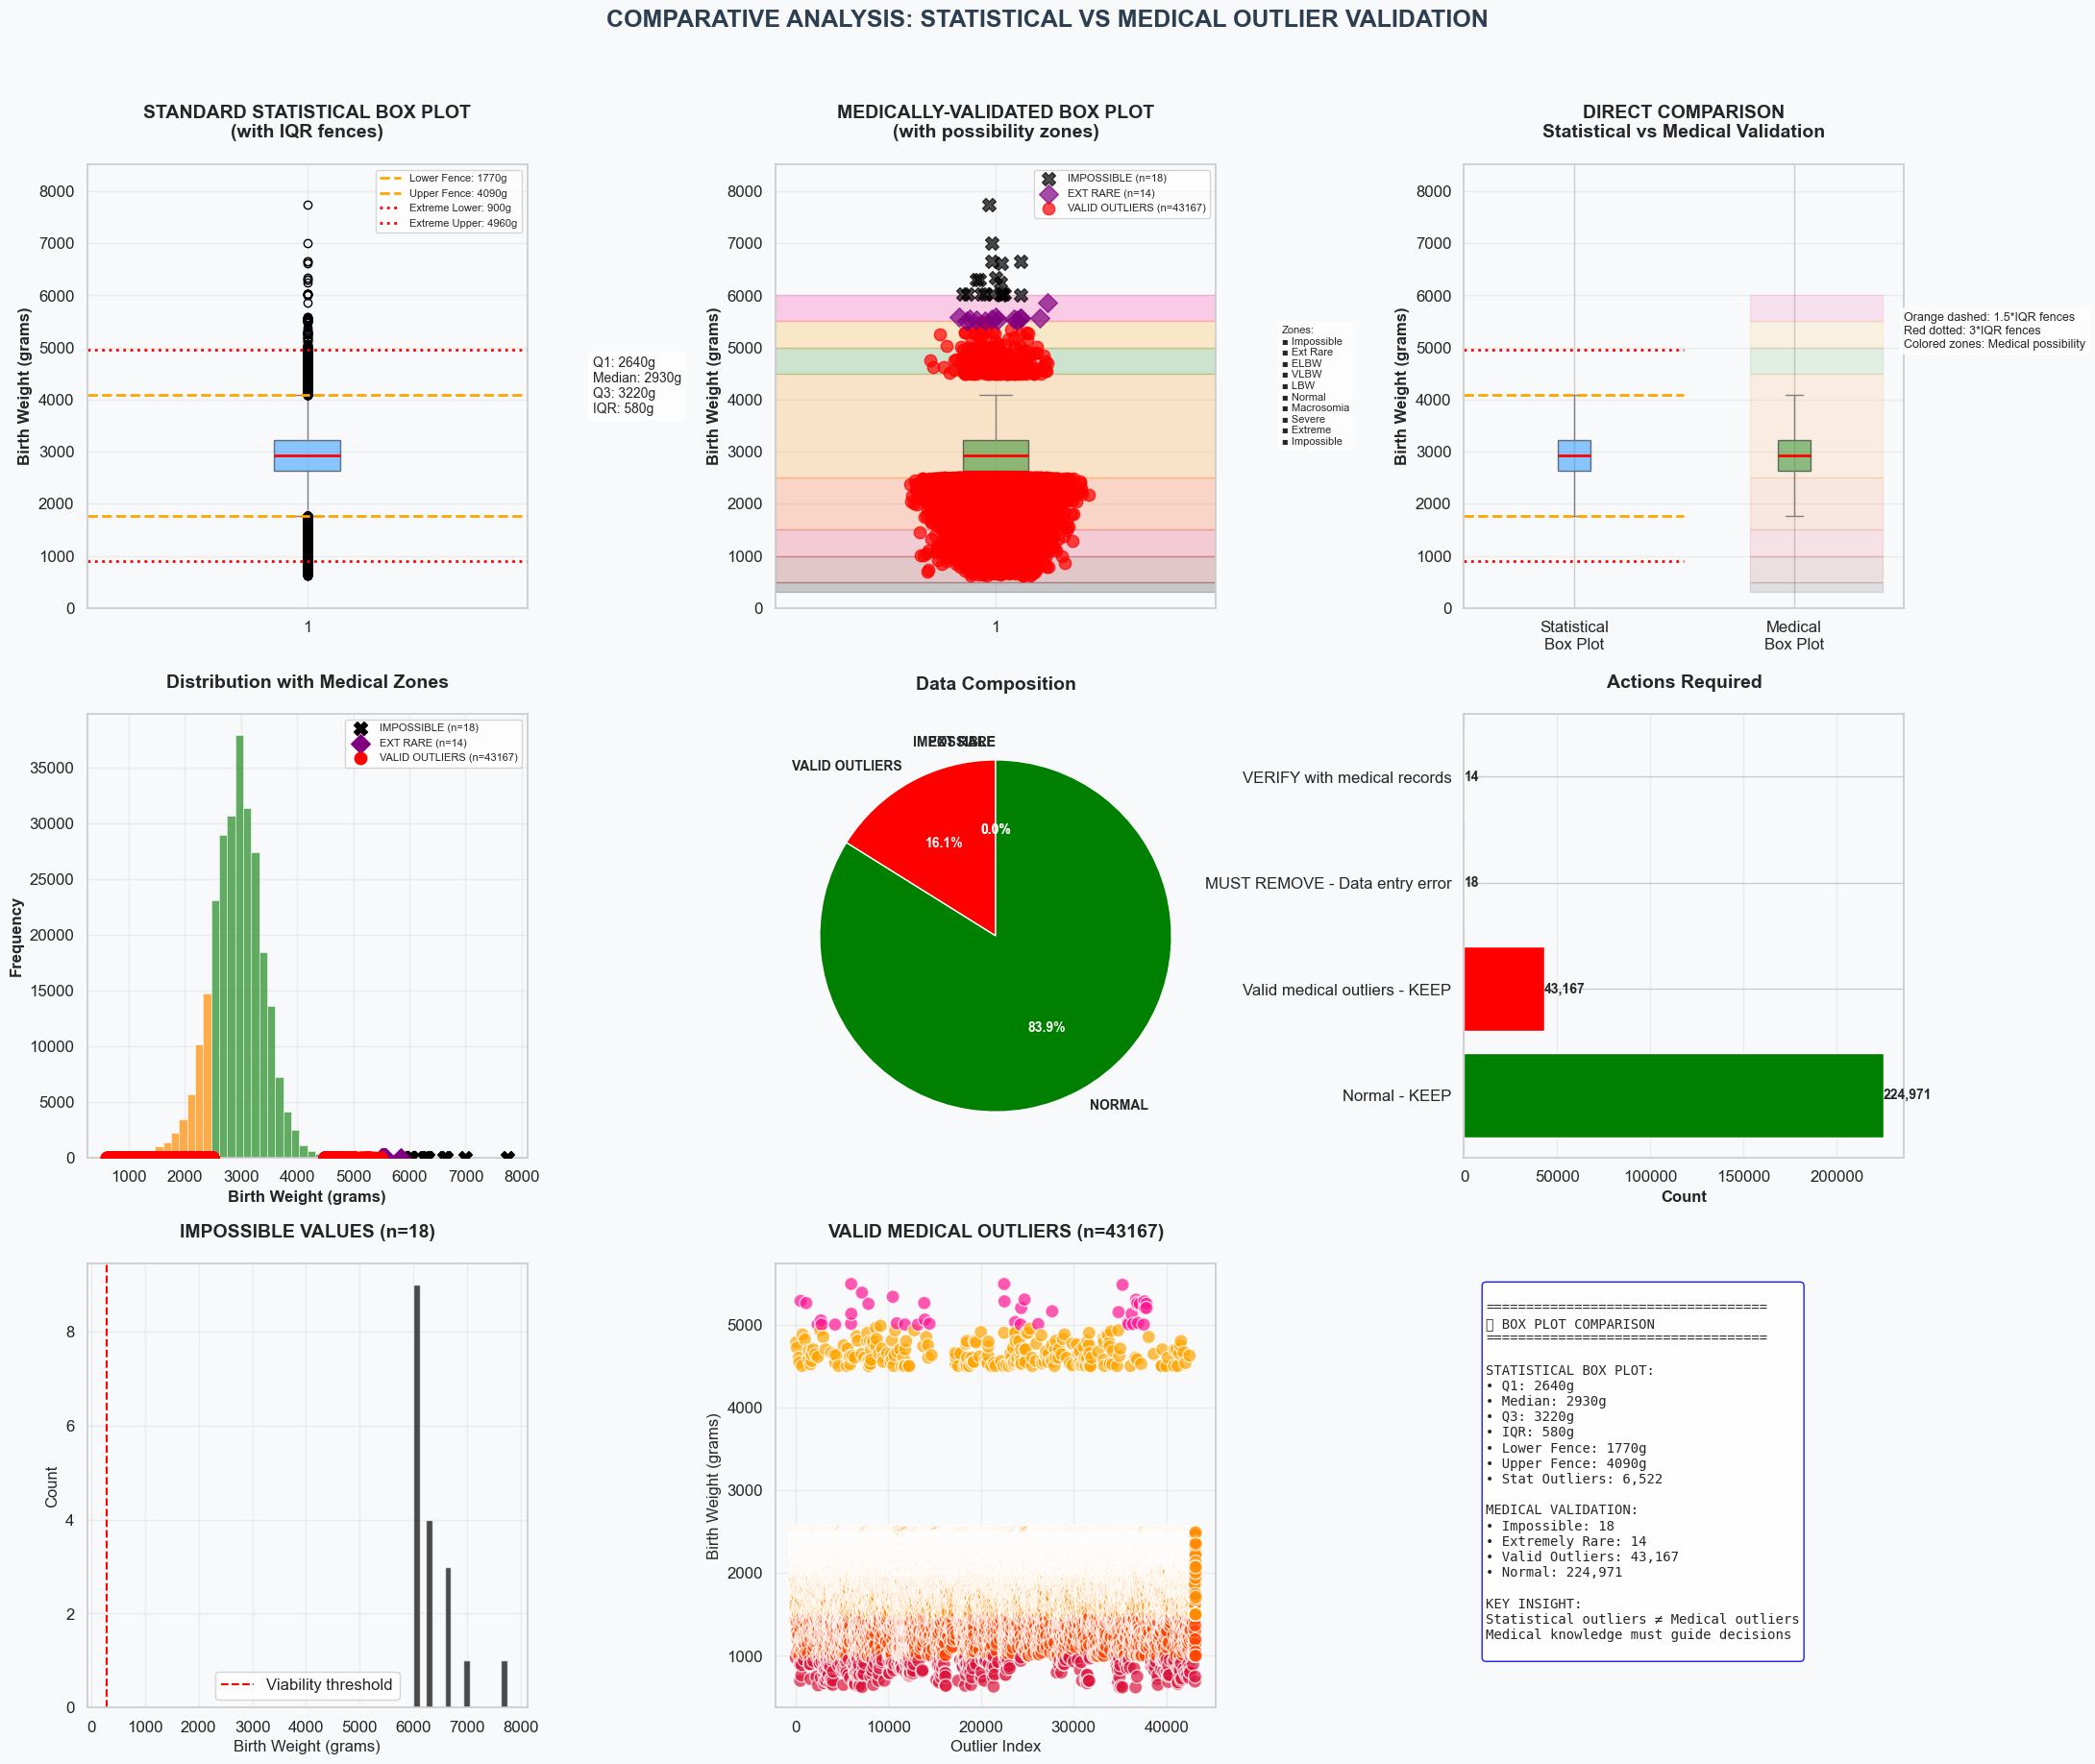

✅ Saved: comparative_boxplot_validation.png

────────────────────────────────────────────────────────────────────────────────
📁 STEP 7: CREATING DETAILED EXCEL REPORT
────────────────────────────────────────────────────────────────────────────────
✅ Excel report saved: final_outlier_validation_report.xlsx

────────────────────────────────────────────────────────────────────────────────
📋 STEP 8: FINAL RECOMMENDATIONS
────────────────────────────────────────────────────────────────────────────────

🎯 FINAL OUTLIER VALIDATION RESULTS

📊 COMPARATIVE SUMMARY:
   • Statistical outliers (IQR method): 6,522
   • Medically impossible values: 18
   • Extremely rare (needs verification): 14
   • Valid medical outliers: 43,167

❌ IMPOSSIBLE VALUES - MUST REMOVE:
   • Count: 18
   • Range: 6000 - 7740g
   • These are data entry errors and should be removed

⚠️ EXTREMELY RARE - NEEDS VERIFICATION:
   • Count: 14
   • Range: 5510 - 5850g

✅ VALID MEDICAL OUTLIERS - KEEP FOR ANALYSIS:
   • Count: 43,

In [10]:
# ============================================
# FINAL STEP: VALIDATE OUTLIERS - POSSIBLE VS IMPOSSIBLE
# WITH COMPARATIVE BOX PLOTS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: LOAD YOUR DATA
# ============================================
print("="*80)
print("🔍 FINAL OUTLIER VALIDATION: POSSIBLE VS IMPOSSIBLE")
print("="*80)

# Update this path to your actual file location
file_path = Path("../../../../data/raw/2020_Birth_Final.xlsx")  # Change this path
df = pd.read_excel(file_path)

# Define target variable
TARGET = 'Birth_Weight(grams)'  # Change if needed

# Get data
data = df[TARGET].dropna()
original_data = df[TARGET]

print(f"\n📌 DATASET OVERVIEW:")
print(f"   • Total records: {len(original_data):,}")
print(f"   • Valid records: {len(data):,}")
print(f"   • Range: {data.min():.0f} - {data.max():.0f}g")

# ============================================
# STEP 2: CALCULATE STATISTICAL PARAMETERS
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 2: CALCULATING STATISTICAL PARAMETERS")
print('─'*80)

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
median = data.median()
mean = data.mean()
std = data.std()

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
lower_fence_extreme = Q1 - 3 * IQR
upper_fence_extreme = Q3 + 3 * IQR

print(f"\n📈 STATISTICAL SUMMARY:")
print(f"   • Mean: {mean:.1f}g")
print(f"   • Median: {median:.1f}g")
print(f"   • Q1 (25th): {Q1:.1f}g")
print(f"   • Q3 (75th): {Q3:.1f}g")
print(f"   • IQR: {IQR:.1f}g")
print(f"   • Lower Fence (1.5*IQR): {lower_fence:.1f}g")
print(f"   • Upper Fence (1.5*IQR): {upper_fence:.1f}g")
print(f"   • Extreme Lower (3*IQR): {lower_fence_extreme:.1f}g")
print(f"   • Extreme Upper (3*IQR): {upper_fence_extreme:.1f}g")

# ============================================
# STEP 3: DEFINE MEDICAL POSSIBILITY CRITERIA
# ============================================
print(f"\n{'─'*80}")
print("🏥 STEP 3: DEFINING MEDICAL POSSIBILITY CRITERIA")
print('─'*80)

# WHO and Medical Literature Based Criteria
medical_possibility = {
    'Impossible - Data Error': {
        'range': [0, 299],
        'color': '#000000',
        'reason': 'Biologically impossible for live birth',
        'action': 'MUST REMOVE - Data entry error',
        'plot_position': 1
    },
    'Extremely Rare - Borderline Viable': {
        'range': [300, 499],
        'color': '#8B0000',
        'reason': 'Extremely rare, only few documented cases worldwide',
        'action': 'VERIFY with medical records',
        'plot_position': 2
    },
    'Extremely Low Birth Weight (ELBW) - Possible': {
        'range': [500, 999],
        'color': '#DC143C',
        'reason': 'Possible with intensive care, though high mortality',
        'action': 'Valid medical outliers - KEEP',
        'plot_position': 3
    },
    'Very Low Birth Weight (VLBW) - Possible': {
        'range': [1000, 1499],
        'color': '#FF4500',
        'reason': 'Possible, requires NICU care',
        'action': 'Valid medical outliers - KEEP',
        'plot_position': 4
    },
    'Low Birth Weight (LBW) - Possible': {
        'range': [1500, 2499],
        'color': '#FF8C00',
        'reason': 'Common, may require monitoring',
        'action': 'Valid medical outliers - KEEP',
        'plot_position': 5
    },
    'Normal Birth Weight': {
        'range': [2500, 4499],
        'color': '#228B22',
        'reason': 'Normal healthy range',
        'action': 'Normal - KEEP',
        'plot_position': 6
    },
    'Macrosomia - Possible': {
        'range': [4500, 4999],
        'color': '#FFA500',
        'reason': 'Possible, risk of birth complications',
        'action': 'Valid medical outliers - KEEP',
        'plot_position': 7
    },
    'Severe Macrosomia - Rare but Possible': {
        'range': [5000, 5499],
        'color': '#FF1493',
        'reason': 'Rare but documented, very high risk',
        'action': 'Valid medical outliers - KEEP',
        'plot_position': 8
    },
    'Extreme Macrosomia - Extremely Rare': {
        'range': [5500, 5999],
        'color': '#800080',
        'reason': 'Extremely rare, exceptional cases',
        'action': 'VERIFY with medical records',
        'plot_position': 9
    },
    'Impossible - Data Error': {
        'range': [6000, float('inf')],
        'color': '#000000',
        'reason': 'Biologically impossible, likely data error',
        'action': 'MUST REMOVE - Data entry error',
        'plot_position': 10
    }
}

print("\n📋 Medical Possibility Classification:")
for category, details in medical_possibility.items():
    max_val = '∞' if details['range'][1] == float('inf') else f"{details['range'][1]:,}"
    print(f"   • {category}: {details['range'][0]:,} - {max_val}g")
    print(f"     Reason: {details['reason']}")
    print(f"     Action: {details['action']}")

# ============================================
# STEP 4: CLASSIFY EACH RECORD
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 4: CLASSIFYING ALL RECORDS")
print('─'*80)

# Create classification DataFrame with all variables
classification = []
for idx, value in data.items():
    for category, details in medical_possibility.items():
        if details['range'][0] <= value <= details['range'][1]:
            # Get the original row data
            original_row = df.loc[idx].to_dict()
            
            record = {
                'index': idx,
                'birth_weight': value,
                'possibility_category': category,
                'reason': details['reason'],
                'action': details['action'],
                'color': details['color'],
                'plot_position': details['plot_position']
            }
            
            # Add all other variables from the original dataframe
            for col in df.columns:
                if col != TARGET:
                    record[col] = original_row.get(col, 'N/A')
            
            classification.append(record)
            break

class_df = pd.DataFrame(classification)

# Add statistical outlier flags
class_df['is_statistical_outlier'] = (
    (class_df['birth_weight'] < lower_fence) | 
    (class_df['birth_weight'] > upper_fence)
)

class_df['z_score'] = np.abs(stats.zscore(class_df['birth_weight']))

# Summary by possibility category
possibility_summary = class_df.groupby(['possibility_category', 'action']).agg({
    'birth_weight': ['count', 'mean', 'min', 'max'],
    'is_statistical_outlier': 'sum'
}).round(1)

possibility_summary.columns = ['Count', 'Mean', 'Min', 'Max', 'Stat_Outliers']
possibility_summary = possibility_summary.reset_index()

print("\n📈 CLASSIFICATION SUMMARY:")
for _, row in possibility_summary.iterrows():
    pct = (row['Count'] / len(data) * 100)
    print(f"\n   {row['possibility_category']}:")
    print(f"      • Count: {row['Count']:,} ({pct:.1f}%)")
    print(f"      • Range: {row['Min']:.0f} - {row['Max']:.0f}g")
    print(f"      • Statistical outliers in this group: {row['Stat_Outliers']}")

# ============================================
# STEP 5: IDENTIFY KEY GROUPS
# ============================================
print(f"\n{'─'*80}")
print("🎯 STEP 5: IDENTIFYING KEY GROUPS")
print('─'*80)

# Group 1: IMPOSSIBLE VALUES - Must be removed
impossible_values = class_df[
    class_df['action'].str.contains('MUST REMOVE')
]

# Group 2: EXTREMELY RARE - Needs verification
rare_values = class_df[
    class_df['action'].str.contains('VERIFY')
]

# Group 3: VALID MEDICAL OUTLIERS - Keep for analysis
valid_outliers = class_df[
    (class_df['action'].str.contains('KEEP')) & 
    (class_df['possibility_category'] != 'Normal Birth Weight')
]

# Group 4: NORMAL VALUES
normal_values = class_df[
    class_df['possibility_category'] == 'Normal Birth Weight'
]

print(f"\n📊 KEY GROUPS IDENTIFIED:")
print(f"\n   ❌ IMPOSSIBLE VALUES (MUST REMOVE):")
print(f"      • Count: {len(impossible_values):,}")
if len(impossible_values) > 0:
    print(f"      • Range: {impossible_values['birth_weight'].min():.0f} - {impossible_values['birth_weight'].max():.0f}g")

print(f"\n   ⚠️ EXTREMELY RARE (NEEDS VERIFICATION):")
print(f"      • Count: {len(rare_values):,}")
if len(rare_values) > 0:
    print(f"      • Range: {rare_values['birth_weight'].min():.0f} - {rare_values['birth_weight'].max():.0f}g")

print(f"\n   ✅ VALID MEDICAL OUTLIERS (KEEP):")
print(f"      • Count: {len(valid_outliers):,}")

print(f"\n   📊 NORMAL VALUES:")
print(f"      • Count: {len(normal_values):,}")

# ============================================
# STEP 6: COMPARATIVE BOX PLOTS - STATISTICAL VS MEDICAL
# ============================================
print(f"\n{'─'*80}")
print("📊 STEP 6: CREATING COMPARATIVE BOX PLOTS")
print('─'*80)

# Create a comprehensive figure with comparative box plots
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#f8f9fa')

# 1. STANDARD STATISTICAL BOX PLOT (Left side)
ax1 = plt.subplot(3, 3, 1)
ax1.set_facecolor('#f8f9fa')

bp1 = ax1.boxplot(data, patch_artist=True, showfliers=True)
bp1['boxes'][0].set_facecolor('#1E90FF')
bp1['boxes'][0].set_alpha(0.5)
bp1['whiskers'][0].set_color('gray')
bp1['whiskers'][1].set_color('gray')
bp1['caps'][0].set_color('gray')
bp1['caps'][1].set_color('gray')
bp1['medians'][0].set_color('red')
bp1['medians'][0].set_linewidth(2)

# Add statistical fence lines
ax1.axhline(y=lower_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence:.0f}g')
ax1.axhline(y=upper_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence:.0f}g')
ax1.axhline(y=lower_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme:.0f}g')
ax1.axhline(y=upper_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme:.0f}g')

ax1.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax1.set_title('STANDARD STATISTICAL BOX PLOT\n(with IQR fences)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(data.max(), upper_fence_extreme) * 1.1)

# Add statistical summary text
stats_text = f"Q1: {Q1:.0f}g\nMedian: {median:.0f}g\nQ3: {Q3:.0f}g\nIQR: {IQR:.0f}g"
ax1.text(1.15, 0.5, stats_text, transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 2. MEDICALLY-VALIDATED BOX PLOT (Middle)
ax2 = plt.subplot(3, 3, 2)
ax2.set_facecolor('#f8f9fa')

bp2 = ax2.boxplot(data, patch_artist=True, showfliers=False)
bp2['boxes'][0].set_facecolor('#228B22')
bp2['boxes'][0].set_alpha(0.5)
bp2['whiskers'][0].set_color('gray')
bp2['whiskers'][1].set_color('gray')
bp2['caps'][0].set_color('gray')
bp2['caps'][1].set_color('gray')
bp2['medians'][0].set_color('red')
bp2['medians'][0].set_linewidth(2)

# Add medical possibility zone boundaries
medical_boundaries = [300, 500, 1000, 1500, 2500, 4500, 5000, 5500, 6000]
colors = ['black', '#8B0000', '#DC143C', '#FF4500', '#FF8C00', '#228B22', '#FFA500', '#FF1493', '#800080', 'black']
labels = ['Impossible', 'Ext Rare', 'ELBW', 'VLBW', 'LBW', 'Normal', 'Macro', 'Severe', 'Extreme', 'Impossible']

for i, boundary in enumerate(medical_boundaries[:-1]):
    ax2.axhspan(boundary, medical_boundaries[i+1], alpha=0.2, color=colors[i])

# Add colored scatter for different groups
if len(impossible_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(impossible_values))], 
               impossible_values['birth_weight'], 
               color='black', alpha=0.7, marker='X', s=100,
               label=f'IMPOSSIBLE (n={len(impossible_values)})', zorder=5)

if len(rare_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(rare_values))], 
               rare_values['birth_weight'], 
               color='purple', alpha=0.7, marker='D', s=100,
               label=f'EXT RARE (n={len(rare_values)})', zorder=5)

if len(valid_outliers) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(valid_outliers))], 
               valid_outliers['birth_weight'], 
               color='red', alpha=0.7, s=80,
               label=f'VALID OUTLIERS (n={len(valid_outliers)})', zorder=4)

ax2.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax2.set_title('MEDICALLY-VALIDATED BOX PLOT\n(with possibility zones)', 
             fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(data.max(), 6000) * 1.1)

# Add medical zone legend
zone_text = "Zones:\n■ Impossible\n■ Ext Rare\n■ ELBW\n■ VLBW\n■ LBW\n■ Normal\n■ Macrosomia\n■ Severe\n■ Extreme\n■ Impossible"
ax2.text(1.15, 0.5, zone_text, transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 3. COMBINED COMPARISON PLOT (Right side)
ax3 = plt.subplot(3, 3, 3)
ax3.set_facecolor('#f8f9fa')

# Create side-by-side box plots
data_to_plot = [data, data]
positions = [1, 2]
bp3 = ax3.boxplot(data_to_plot, positions=positions, patch_artist=True, showfliers=False)
bp3['boxes'][0].set_facecolor('#1E90FF')
bp3['boxes'][0].set_alpha(0.5)
bp3['boxes'][1].set_facecolor('#228B22')
bp3['boxes'][1].set_alpha(0.5)
bp3['whiskers'][0].set_color('gray')
bp3['whiskers'][1].set_color('gray')
bp3['whiskers'][2].set_color('gray')
bp3['whiskers'][3].set_color('gray')
bp3['caps'][0].set_color('gray')
bp3['caps'][1].set_color('gray')
bp3['caps'][2].set_color('gray')
bp3['caps'][3].set_color('gray')
bp3['medians'][0].set_color('red')
bp3['medians'][1].set_color('red')
bp3['medians'][0].set_linewidth(2)
bp3['medians'][1].set_linewidth(2)

# Add statistical fences on first box
ax3.plot([0.5, 1.5], [lower_fence, lower_fence], 'orange', linestyle='--', linewidth=2)
ax3.plot([0.5, 1.5], [upper_fence, upper_fence], 'orange', linestyle='--', linewidth=2)
ax3.plot([0.5, 1.5], [lower_fence_extreme, lower_fence_extreme], 'red', linestyle=':', linewidth=2)
ax3.plot([0.5, 1.5], [upper_fence_extreme, upper_fence_extreme], 'red', linestyle=':', linewidth=2)

# Add medical zones on second box
for i, boundary in enumerate(medical_boundaries[:-1]):
    ax3.axhspan(boundary, medical_boundaries[i+1], alpha=0.1, color=colors[i], xmin=0.65, xmax=0.95)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Statistical\nBox Plot', 'Medical\nBox Plot'])
ax3.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax3.set_title('DIRECT COMPARISON\nStatistical vs Medical Validation', 
             fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, max(data.max(), 6000) * 1.1)

# Add explanation
compare_text = "Orange dashed: 1.5*IQR fences\nRed dotted: 3*IQR fences\nColored zones: Medical possibility"
ax3.text(2.5, 5000, compare_text, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Main Distribution with Clear Grouping
ax4 = plt.subplot(3, 3, 4)
ax4.set_facecolor('#f8f9fa')

n, bins, patches = ax4.hist(data, bins=50, edgecolor='white', linewidth=0.5, alpha=0.7)

# Color by possibility
for i in range(len(bins)-1):
    bin_center = (bins[i] + bins[i+1]) / 2
    for category, details in medical_possibility.items():
        if details['range'][0] <= bin_center <= details['range'][1]:
            patches[i].set_facecolor(details['color'])
            patches[i].set_alpha(0.7)
            break

# Highlight different groups with markers
if len(impossible_values) > 0:
    ax4.scatter(impossible_values['birth_weight'], 
               [5]*len(impossible_values), 
               color='black', marker='X', s=100, 
               label=f'IMPOSSIBLE (n={len(impossible_values)})', zorder=5)

if len(rare_values) > 0:
    ax4.scatter(rare_values['birth_weight'], 
               [10]*len(rare_values), 
               color='purple', marker='D', s=100, 
               label=f'EXT RARE (n={len(rare_values)})', zorder=5)

if len(valid_outliers) > 0:
    ax4.scatter(valid_outliers['birth_weight'], 
               [15]*len(valid_outliers), 
               color='red', marker='o', s=80, 
               label=f'VALID OUTLIERS (n={len(valid_outliers)})', zorder=5)

ax4.set_xlabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Distribution with Medical Zones', fontsize=14, fontweight='bold', pad=20)
ax4.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax4.grid(True, alpha=0.3)

# 5. Group Composition Pie Chart
ax5 = plt.subplot(3, 3, 5)
ax5.set_facecolor('#f8f9fa')

group_sizes = [
    len(impossible_values),
    len(rare_values),
    len(valid_outliers),
    len(normal_values)
]
group_labels = ['IMPOSSIBLE', 'EXT RARE', 'VALID OUTLIERS', 'NORMAL']
group_colors = ['black', 'purple', 'red', 'green']

wedges, texts, autotexts = ax5.pie(group_sizes, 
                                    labels=group_labels,
                                    autopct='%1.1f%%',
                                    colors=group_colors,
                                    startangle=90,
                                    textprops={'fontsize': 10, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax5.set_title('Data Composition', fontsize=14, fontweight='bold', pad=20)

# 6. Action Required Bar Chart
ax6 = plt.subplot(3, 3, 6)
ax6.set_facecolor('#f8f9fa')

action_counts = class_df['action'].value_counts()
action_colors = {
    'MUST REMOVE - Data entry error': 'black',
    'VERIFY with medical records': 'purple',
    'Valid medical outliers - KEEP': 'red',
    'Normal - KEEP': 'green'
}
colors = [action_colors.get(action, 'gray') for action in action_counts.index]

bars = ax6.barh(range(len(action_counts)), action_counts.values, color=colors, edgecolor='white')
ax6.set_yticks(range(len(action_counts)))
ax6.set_yticklabels([a[:30] + '...' if len(a) > 30 else a for a in action_counts.index])
ax6.set_xlabel('Count', fontsize=12, fontweight='bold')
ax6.set_title('Actions Required', fontsize=14, fontweight='bold', pad=20)

for bar, count in zip(bars, action_counts.values):
    ax6.text(count + 1, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=10, fontweight='bold')

ax6.grid(True, alpha=0.3, axis='x')

# 7. Impossible Values Distribution
ax7 = plt.subplot(3, 3, 7)
ax7.set_facecolor('#f8f9fa')

if len(impossible_values) > 0:
    ax7.hist(impossible_values['birth_weight'], bins=15, color='black', alpha=0.7, edgecolor='white')
    ax7.set_xlabel('Birth Weight (grams)', fontsize=12)
    ax7.set_ylabel('Count', fontsize=12)
    ax7.set_title(f'IMPOSSIBLE VALUES (n={len(impossible_values)})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax7.axvline(x=300, color='red', linestyle='--', label='Viability threshold')
    ax7.legend()
    ax7.grid(True, alpha=0.3)
else:
    ax7.text(0.5, 0.5, 'NO IMPOSSIBLE VALUES', ha='center', va='center', fontsize=14, fontweight='bold')
    ax7.set_title('Impossible Values', fontsize=14, fontweight='bold')

# 8. Valid Outliers Distribution
ax8 = plt.subplot(3, 3, 8)
ax8.set_facecolor('#f8f9fa')

if len(valid_outliers) > 0:
    colors = [medical_possibility[cat]['color'] for cat in valid_outliers['possibility_category']]
    scatter = ax8.scatter(range(len(valid_outliers)), valid_outliers['birth_weight'], 
                         c=colors, s=100, alpha=0.7, edgecolor='white')
    
    ax8.set_xlabel('Outlier Index', fontsize=12)
    ax8.set_ylabel('Birth Weight (grams)', fontsize=12)
    ax8.set_title(f'VALID MEDICAL OUTLIERS (n={len(valid_outliers)})', 
                 fontsize=14, fontweight='bold', pad=20)
    ax8.grid(True, alpha=0.3)
else:
    ax8.text(0.5, 0.5, 'NO VALID OUTLIERS', ha='center', va='center', fontsize=14, fontweight='bold')
    ax8.set_title('Valid Medical Outliers', fontsize=14, fontweight='bold')

# 9. Comparison Summary
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
ax9.set_facecolor('#f8f9fa')

comparison_summary = f"""
{'='*35}
📊 BOX PLOT COMPARISON
{'='*35}

STATISTICAL BOX PLOT:
• Q1: {Q1:.0f}g
• Median: {median:.0f}g
• Q3: {Q3:.0f}g
• IQR: {IQR:.0f}g
• Lower Fence: {lower_fence:.0f}g
• Upper Fence: {upper_fence:.0f}g
• Stat Outliers: {len(class_df[class_df['is_statistical_outlier']]):,}

MEDICAL VALIDATION:
• Impossible: {len(impossible_values):,}
• Extremely Rare: {len(rare_values):,}
• Valid Outliers: {len(valid_outliers):,}
• Normal: {len(normal_values):,}

KEY INSIGHT:
Statistical outliers ≠ Medical outliers
Medical knowledge must guide decisions
"""

ax9.text(0.05, 0.95, comparison_summary, fontsize=10, 
         verticalalignment='top', family='monospace',
         transform=ax9.transAxes,
         bbox=dict(boxstyle='round', facecolor='white', 
                   edgecolor='blue', alpha=0.9))

plt.suptitle('COMPARATIVE ANALYSIS: STATISTICAL VS MEDICAL OUTLIER VALIDATION', 
            fontsize=18, fontweight='bold', y=1.02, color='#2c3e50')
plt.tight_layout()
plt.savefig('comparative_boxplot_validation.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print("✅ Saved: comparative_boxplot_validation.png")

# ============================================
# STEP 7: CREATE DETAILED EXCEL REPORT
# ============================================
print(f"\n{'─'*80}")
print("📁 STEP 7: CREATING DETAILED EXCEL REPORT")
print('─'*80)

excel_filename = 'final_outlier_validation_report.xlsx'

with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    
    # Sheet 1: Executive Summary
    summary_data = {
        'Category': ['Total Records', 'Valid Records', 'IMPOSSIBLE (Remove)', 'EXTREMELY RARE (Verify)', 
                     'VALID OUTLIERS (Keep)', 'NORMAL (Keep)', 'Statistical Outliers (IQR)'],
        'Count': [
            len(original_data),
            len(data),
            len(impossible_values),
            len(rare_values),
            len(valid_outliers),
            len(normal_values),
            len(class_df[class_df['is_statistical_outlier']])
        ],
        'Percentage': [
            100.0,
            100.0,
            round(len(impossible_values)/len(data)*100, 1),
            round(len(rare_values)/len(data)*100, 1),
            round(len(valid_outliers)/len(data)*100, 1),
            round(len(normal_values)/len(data)*100, 1),
            round(len(class_df[class_df['is_statistical_outlier']])/len(data)*100, 1)
        ],
        'Action': [
            '-',
            '-',
            'MUST REMOVE - Data entry error',
            'Verify with medical records',
            'Keep for analysis',
            'Keep as normal',
            'For reference only'
        ]
    }
    pd.DataFrame(summary_data).to_excel(writer, sheet_name='Executive_Summary', index=False)
    
    # Sheet 2: Statistical Summary
    stats_df = pd.DataFrame({
        'Parameter': ['Mean', 'Median', 'Q1', 'Q3', 'IQR', 'Std Dev', 
                      'Lower Fence', 'Upper Fence', 'Extreme Lower', 'Extreme Upper'],
        'Value': [mean, median, Q1, Q3, IQR, std, 
                  lower_fence, upper_fence, lower_fence_extreme, upper_fence_extreme]
    })
    stats_df.to_excel(writer, sheet_name='Statistical_Summary', index=False)
    
    # Sheet 3: ALL IMPOSSIBLE VALUES (MUST REMOVE)
    if len(impossible_values) > 0:
        impossible_values.to_excel(writer, sheet_name='IMPOSSIBLE_Remove', index=False)
    
    # Sheet 4: EXTREMELY RARE (Need Verification)
    if len(rare_values) > 0:
        rare_values.to_excel(writer, sheet_name='EXTREME_RARE_Verify', index=False)
    
    # Sheet 5: VALID MEDICAL OUTLIERS (Keep)
    if len(valid_outliers) > 0:
        valid_outliers.to_excel(writer, sheet_name='VALID_Outliers_Keep', index=False)
    
    # Sheet 6: NORMAL VALUES
    if len(normal_values) > 0:
        normal_values.to_excel(writer, sheet_name='NORMAL_Values', index=False)
    
    # Sheet 7: Complete Dataset with Classification
    class_df.to_excel(writer, sheet_name='Complete_Dataset', index=False)
    
    # Sheet 8: Statistical Outliers Only
    stat_outliers = class_df[class_df['is_statistical_outlier']]
    stat_outliers.to_excel(writer, sheet_name='Statistical_Outliers', index=False)

print(f"✅ Excel report saved: {excel_filename}")

# ============================================
# STEP 8: FINAL RECOMMENDATIONS
# ============================================
print(f"\n{'─'*80}")
print("📋 STEP 8: FINAL RECOMMENDATIONS")
print('─'*80)

print(f"\n{'='*80}")
print("🎯 FINAL OUTLIER VALIDATION RESULTS")
print('='*80)

print(f"\n📊 COMPARATIVE SUMMARY:")
print(f"   • Statistical outliers (IQR method): {len(class_df[class_df['is_statistical_outlier']]):,}")
print(f"   • Medically impossible values: {len(impossible_values):,}")
print(f"   • Extremely rare (needs verification): {len(rare_values):,}")
print(f"   • Valid medical outliers: {len(valid_outliers):,}")

print(f"\n❌ IMPOSSIBLE VALUES - MUST REMOVE:")
if len(impossible_values) > 0:
    print(f"   • Count: {len(impossible_values):,}")
    print(f"   • Range: {impossible_values['birth_weight'].min():.0f} - {impossible_values['birth_weight'].max():.0f}g")
    print(f"   • These are data entry errors and should be removed")

print(f"\n⚠️ EXTREMELY RARE - NEEDS VERIFICATION:")
if len(rare_values) > 0:
    print(f"   • Count: {len(rare_values):,}")
    print(f"   • Range: {rare_values['birth_weight'].min():.0f} - {rare_values['birth_weight'].max():.0f}g")

print(f"\n✅ VALID MEDICAL OUTLIERS - KEEP FOR ANALYSIS:")
if len(valid_outliers) > 0:
    print(f"   • Count: {len(valid_outliers):,}")
    print(f"   • These are clinically significant cases")

print(f"\n{'='*80}")
print("📋 FINAL RECOMMENDATIONS:")
print('='*80)
print(f"\n1. ❌ REMOVE {len(impossible_values):,} records (biologically impossible)")
print(f"2. ⚠️ VERIFY {len(rare_values):,} records with medical records")
print(f"3. ✅ KEEP {len(valid_outliers):,} valid medical outliers for analysis")
print(f"4. 📊 PROCEED with analysis including {len(valid_outliers) + len(normal_values):,} valid records")

print(f"\n📁 FILES CREATED:")
print(f"   • PNG: comparative_boxplot_validation.png")
print(f"   • Excel: {excel_filename}")

print(f"\n{'='*80}")
print("✅ FINAL OUTLIER VALIDATION COMPLETE")
print('='*80)

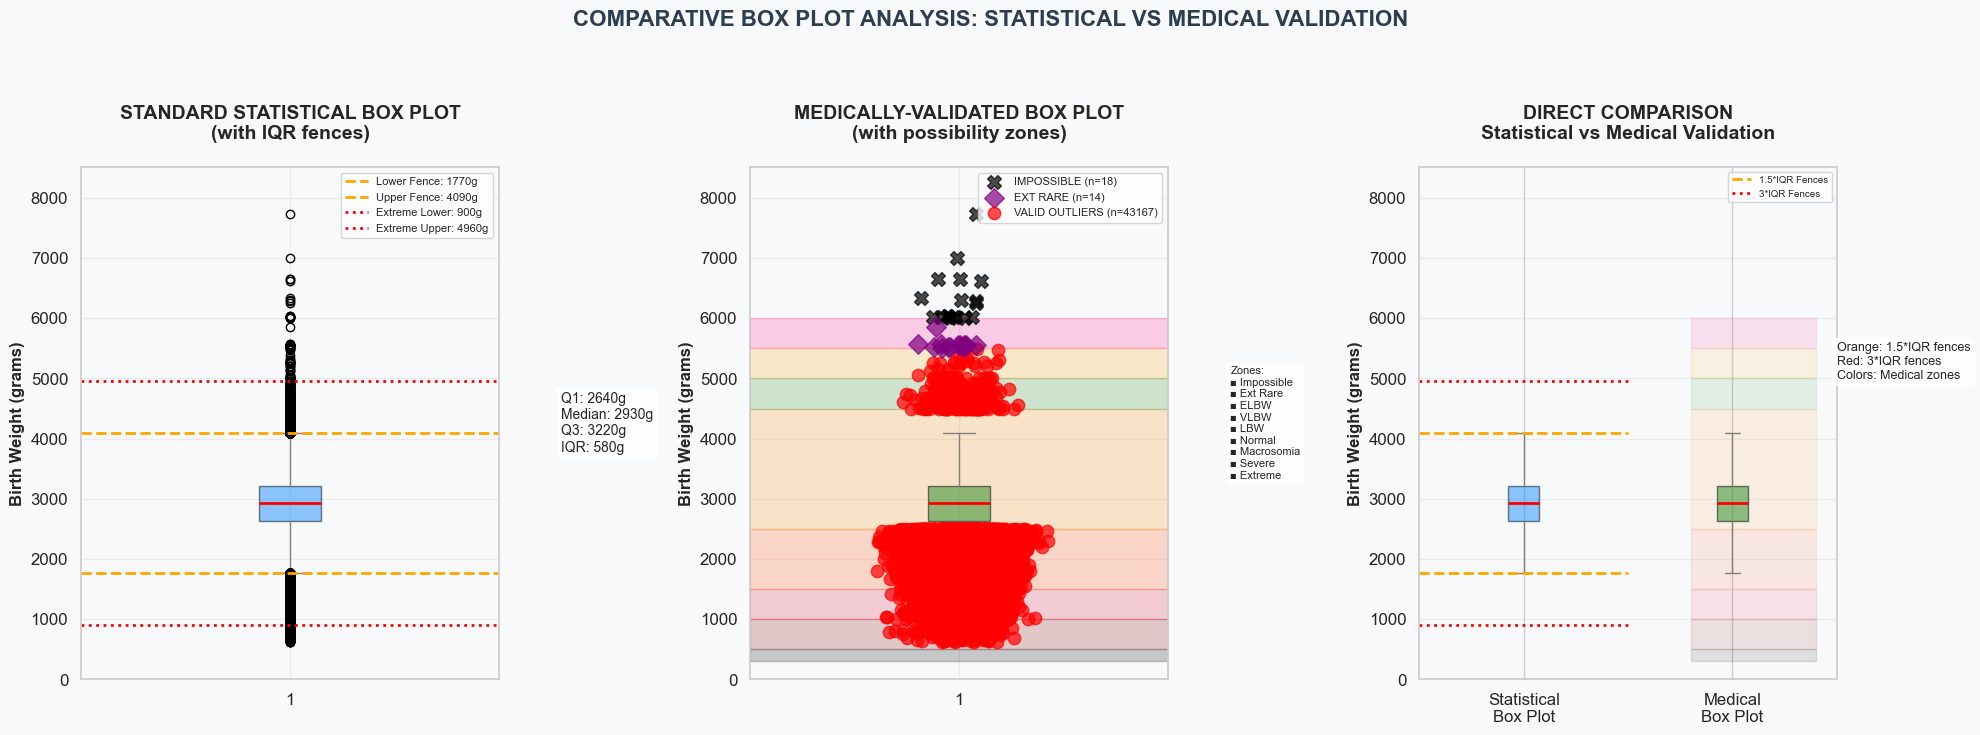

✅ Generated 3 comparative box plots
✅ Saved: comparative_boxplots.png


In [11]:
# ============================================
# COMPARATIVE BOX PLOTS - STATISTICAL VS MEDICAL
# ============================================

# Create a comprehensive figure with comparative box plots
fig = plt.figure(figsize=(20, 7))
fig.patch.set_facecolor('#f8f9fa')

# 1. STANDARD STATISTICAL BOX PLOT (Left)
ax1 = plt.subplot(1, 3, 1)
ax1.set_facecolor('#f8f9fa')

bp1 = ax1.boxplot(data, patch_artist=True, showfliers=True)
bp1['boxes'][0].set_facecolor('#1E90FF')
bp1['boxes'][0].set_alpha(0.5)
bp1['whiskers'][0].set_color('gray')
bp1['whiskers'][1].set_color('gray')
bp1['caps'][0].set_color('gray')
bp1['caps'][1].set_color('gray')
bp1['medians'][0].set_color('red')
bp1['medians'][0].set_linewidth(2)

# Add statistical fence lines
ax1.axhline(y=lower_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Lower Fence: {lower_fence:.0f}g')
ax1.axhline(y=upper_fence, color='orange', linestyle='--', linewidth=2, 
            label=f'Upper Fence: {upper_fence:.0f}g')
ax1.axhline(y=lower_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Lower: {lower_fence_extreme:.0f}g')
ax1.axhline(y=upper_fence_extreme, color='red', linestyle=':', linewidth=2, 
            label=f'Extreme Upper: {upper_fence_extreme:.0f}g')

ax1.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax1.set_title('STANDARD STATISTICAL BOX PLOT\n(with IQR fences)', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, max(data.max(), upper_fence_extreme) * 1.1)

# Add statistical summary text
stats_text = f"Q1: {Q1:.0f}g\nMedian: {median:.0f}g\nQ3: {Q3:.0f}g\nIQR: {IQR:.0f}g"
ax1.text(1.15, 0.5, stats_text, transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 2. MEDICALLY-VALIDATED BOX PLOT (Middle)
ax2 = plt.subplot(1, 3, 2)
ax2.set_facecolor('#f8f9fa')

bp2 = ax2.boxplot(data, patch_artist=True, showfliers=False)
bp2['boxes'][0].set_facecolor('#228B22')
bp2['boxes'][0].set_alpha(0.5)
bp2['whiskers'][0].set_color('gray')
bp2['whiskers'][1].set_color('gray')
bp2['caps'][0].set_color('gray')
bp2['caps'][1].set_color('gray')
bp2['medians'][0].set_color('red')
bp2['medians'][0].set_linewidth(2)

# Add medical possibility zone boundaries
medical_boundaries = [300, 500, 1000, 1500, 2500, 4500, 5000, 5500, 6000]
colors = ['black', '#8B0000', '#DC143C', '#FF4500', '#FF8C00', '#228B22', '#FFA500', '#FF1493', '#800080']

for i, boundary in enumerate(medical_boundaries[:-1]):
    ax2.axhspan(boundary, medical_boundaries[i+1], alpha=0.2, color=colors[i])

# Add colored scatter for different groups
if len(impossible_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(impossible_values))], 
               impossible_values['birth_weight'], 
               color='black', alpha=0.7, marker='X', s=100,
               label=f'IMPOSSIBLE (n={len(impossible_values)})', zorder=5)

if len(rare_values) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(rare_values))], 
               rare_values['birth_weight'], 
               color='purple', alpha=0.7, marker='D', s=100,
               label=f'EXT RARE (n={len(rare_values)})', zorder=5)

if len(valid_outliers) > 0:
    ax2.scatter([1 + np.random.normal(0, 0.05, len(valid_outliers))], 
               valid_outliers['birth_weight'], 
               color='red', alpha=0.7, s=80,
               label=f'VALID OUTLIERS (n={len(valid_outliers)})', zorder=4)

ax2.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax2.set_title('MEDICALLY-VALIDATED BOX PLOT\n(with possibility zones)', 
             fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='upper right', fontsize=8, frameon=True, facecolor='white')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, max(data.max(), 6000) * 1.1)

# Add medical zone legend
zone_text = "Zones:\n■ Impossible\n■ Ext Rare\n■ ELBW\n■ VLBW\n■ LBW\n■ Normal\n■ Macrosomia\n■ Severe\n■ Extreme"
ax2.text(1.15, 0.5, zone_text, transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
         verticalalignment='center')

# 3. COMBINED COMPARISON PLOT (Right)
ax3 = plt.subplot(1, 3, 3)
ax3.set_facecolor('#f8f9fa')

# Create side-by-side box plots
data_to_plot = [data, data]
positions = [1, 2]
bp3 = ax3.boxplot(data_to_plot, positions=positions, patch_artist=True, showfliers=False)
bp3['boxes'][0].set_facecolor('#1E90FF')
bp3['boxes'][0].set_alpha(0.5)
bp3['boxes'][1].set_facecolor('#228B22')
bp3['boxes'][1].set_alpha(0.5)
for i in range(4):
    bp3['whiskers'][i].set_color('gray')
    bp3['caps'][i].set_color('gray')
bp3['medians'][0].set_color('red')
bp3['medians'][1].set_color('red')
bp3['medians'][0].set_linewidth(2)
bp3['medians'][1].set_linewidth(2)

# Add statistical fences on first box
ax3.plot([0.5, 1.5], [lower_fence, lower_fence], 'orange', linestyle='--', linewidth=2, label='1.5*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence, upper_fence], 'orange', linestyle='--', linewidth=2)
ax3.plot([0.5, 1.5], [lower_fence_extreme, lower_fence_extreme], 'red', linestyle=':', linewidth=2, label='3*IQR Fences')
ax3.plot([0.5, 1.5], [upper_fence_extreme, upper_fence_extreme], 'red', linestyle=':', linewidth=2)

# Add medical zones on second box
for i, boundary in enumerate(medical_boundaries[:-1]):
    ax3.axhspan(boundary, medical_boundaries[i+1], alpha=0.1, color=colors[i], xmin=0.65, xmax=0.95)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Statistical\nBox Plot', 'Medical\nBox Plot'])
ax3.set_ylabel('Birth Weight (grams)', fontsize=12, fontweight='bold')
ax3.set_title('DIRECT COMPARISON\nStatistical vs Medical Validation', 
             fontsize=14, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, max(data.max(), 6000) * 1.1)
ax3.legend(loc='upper right', fontsize=7, frameon=True, facecolor='white')

# Add explanation
compare_text = "Orange: 1.5*IQR fences\nRed: 3*IQR fences\nColors: Medical zones"
ax3.text(2.5, 5000, compare_text, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('COMPARATIVE BOX PLOT ANALYSIS: STATISTICAL VS MEDICAL VALIDATION', 
            fontsize=16, fontweight='bold', y=1.05, color='#2c3e50')
plt.tight_layout()
plt.savefig('comparative_boxplots.png', dpi=300, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

print("✅ Generated 3 comparative box plots")
print("✅ Saved: comparative_boxplots.png")